# Supplementary Material S5: Classroom Pilot Statistical Analysis

## SCAFFOLD Framework Feasibility and Impact Study

This notebook provides the complete statistical analysis supporting the findings reported in the main paper regarding the classroom pilot of the SCAFFOLD framework for LLM-mediated collaborative learning.


## Setup and Data Loading

### Required Libraries

This notebook uses both Python and R. Install required packages:

```bash
# Python packages
pip install pandas numpy matplotlib seaborn scipy rpy2

# R packages (run in R)
install.packages(c("tidyverse", "lme4", "lmerTest", "sjPlot", "performance", "sandwich", "lmtest"))
```

In [35]:
# Python imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings

# Set up R integration
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr

# Load rpy2 IPython extension for %%R magic
%load_ext rpy2.ipython

# Suppress warnings
warnings.filterwarnings('ignore')

# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Libraries loaded successfully")
print("✓ R integration ready")

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython
✓ Libraries loaded successfully
✓ R integration ready


In [36]:
%%R
# Load R libraries
suppressPackageStartupMessages({
    library(tidyverse)
    library(lme4)
    library(lmerTest)
    library(sjPlot)
    library(performance)
    library(sandwich)
    library(lmtest)
    library(broom.mixed)
})

cat("✓ R libraries loaded successfully\n")

✓ R libraries loaded successfully


### Data Loading and Preparation

We load three main datasets:
1. **Knowledge scores** (T1, T2, T3): Student responses to microcontroller questions
2. **Engagement data**: Student feedback and group assignments
3. **Co-creation levels**: Group-level coding of student participation

In [37]:
# Load data files
data_path = Path('../../Data_analysis/Data')

# 1. Children knowledge data (T1, T2, T3)
df_children = pd.read_csv(data_path / 'Qualtrics/BuildBots_children_T1T4T7T8.csv')

# 2. Engagement data for group assignments and feedback
df_engagement = pd.read_csv(data_path / 'Qualtrics/BuildBots_engagement_children_T1-T7.csv', 
                            encoding='ISO-8859-1')

# 3. Group-level co-creation data
df_cocreation = pd.read_csv(data_path / 'BuildbotAnalysis - LLM analysis.csv', skiprows=1)

# Clean Participant IDs before passing to R (prevents conversion warnings)
df_engagement['Participant ID'] = pd.to_numeric(df_engagement['Participant ID'], errors='coerce')
df_children['Participant ID'] = pd.to_numeric(df_children['Participant ID'], errors='coerce')
df_engagement = df_engagement.dropna(subset=['Participant ID'])
df_children = df_children.dropna(subset=['Participant ID'])

print(f"✓ Data loaded")
print(f"  Children data: {df_children.shape}")
print(f"  Engagement data: {df_engagement.shape}")
print(f"  Co-creation data: {df_cocreation.shape}")

✓ Data loaded
  Children data: (112, 95)
  Engagement data: (194, 34)
  Co-creation data: (11, 43)


## Data Preparation

### Merge datasets and create knowledge scores

**Scoring convention:**
- Correct answer (1) → 1 point
- Incorrect answer (0) → 0 points
- "I don't know" (99) → 0 points

**Two score variables:**
- **score2q:** 2 basic microcontroller questions (0-2) - Available at ALL timepoints
- **score10q:** 10 total questions = 2 basic + 8 LLM-specific (0-10) - Available at T2/T3 ONLY

In [38]:
%%R -i df_children,df_engagement,df_cocreation

# Get participant to group mapping
mapping <- df_engagement %>%
  select(`Participant ID`, Group) %>%
  distinct() %>%
  mutate(
    `Participant ID` = as.numeric(`Participant ID`),
    Group = as.numeric(Group)
  ) %>%
  filter(!is.na(`Participant ID`), !is.na(Group))

# Extract co-creation column
cocreation_col <- "Co-creation Level (0:LLM did it all, 1: concepts by students/rest llm, 2: concepts by the students, co-creation of the mnemonic, 3: mainly by students)"

df_cocreation_clean <- df_cocreation %>%
  select(Group, Cocreation_Level = all_of(cocreation_col)) %>%
  filter(!is.na(Group), !is.na(Cocreation_Level)) %>%
  mutate(Group = as.numeric(Group))

# Check unique timepoints in the data
unique_timepoints <- unique(df_children$Timepoint)
cat("Available timepoints in original data:", paste(unique_timepoints, collapse = ", "), "\n")

# Merge all data
df_merged <- df_children %>%
  mutate(`Participant ID` = as.numeric(`Participant ID`)) %>%
  left_join(mapping, by = "Participant ID") %>%
  filter(!is.na(Group)) %>%
  left_join(df_cocreation_clean, by = "Group") %>%
  filter(!is.na(Cocreation_Level))

# Rename timepoints to match paper nomenclature:
# T1 (pre-test) stays T1
# T7 (immediate post-test) becomes T2
# T8 (delayed post-test) becomes T3
df_merged <- df_merged %>%
  mutate(
    Timepoint_original = Timepoint,  # Keep original for reference
    Timepoint = case_when(
      Timepoint == "T1" ~ "T1",
      Timepoint == "T7" ~ "T2",
      Timepoint == "T8" ~ "T3",
      TRUE ~ Timepoint  # Keep any other timepoints as-is
    )
  )

cat("Timepoints renamed: T1→T1, T7→T2, T8→T3\n\n")

# Count students at T2 (was T7 in original data)
n_students_t2 <- df_merged %>%
  filter(Timepoint == "T2") %>%
  pull(`Participant ID`) %>%
  n_distinct()

# Count groups with co-creation level data
n_groups_cocreation <- n_distinct(df_cocreation_clean$Group)

cat("✓ Data merged successfully\n")
cat(sprintf("  Total students: %d\n", n_distinct(df_merged$`Participant ID`)))
cat(sprintf("  Students at T2 (immediate post-test): %d\n", n_students_t2))
cat(sprintf("  Groups with co-creation data: %d\n", n_groups_cocreation))

Available timepoints in original data: T1, T4, T7, T8 
Timepoints renamed: T1→T1, T7→T2, T8→T3

✓ Data merged successfully
  Total students: 27
  Students at T2 (immediate post-test): 24
  Groups with co-creation data: 9


In [39]:
%%R

# STEP 1: Score the 2 basic microcontroller questions (ALL timepoints)
df_scored <- df_merged %>%
  mutate(
    mc1_raw = as.numeric(microcontrollers_1),
    mc2_raw = as.numeric(microcontrollers_2),
    
    # Score: 1 if correct, 0 if incorrect or "don't know" (99)
    mc1_score = if_else(mc1_raw == 1, 1, 0),
    mc2_score = if_else(mc2_raw == 1, 1, 0),
    
    # score2q: 2 basic questions (0-2) - ALL timepoints
    score2q = mc1_score + mc2_score
  )

# STEP 2: Score the 8 LLM-specific questions (T2 and T3 ONLY)
# These questions were only asked after the LLM interaction
llm_cols <- paste0("LLM_Microcontrollers_", 1:8)

# Score each LLM question
for (i in 1:8) {
  col_name <- paste0("LLM_Microcontrollers_", i)
  score_name <- paste0("llm_mc", i, "_score")
  
  df_scored <- df_scored %>%
    mutate(
      !!score_name := case_when(
        is.na(as.numeric(.data[[col_name]])) ~ NA_real_,
        as.numeric(.data[[col_name]]) == 1 ~ 1,
        as.numeric(.data[[col_name]]) %in% c(0, 99) ~ 0,
        TRUE ~ NA_real_
      )
    )
}

# STEP 3: Calculate score10q (T2/T3 only)
df_scored <- df_scored %>%
  mutate(
    # Sum of all 8 LLM questions
    llm_score8 = llm_mc1_score + llm_mc2_score + llm_mc3_score + llm_mc4_score +
                 llm_mc5_score + llm_mc6_score + llm_mc7_score + llm_mc8_score,
    
    # score10q: 2 basic + 8 LLM (0-10, T2/T3 only)
    score10q = case_when(
      Timepoint %in% c("T2", "T3") & !is.na(score2q) & !is.na(llm_score8) ~ score2q + llm_score8,
      TRUE ~ NA_real_
    )
  )

# STEP 4: Create factors
df_scored <- df_scored %>%
  mutate(
    Group_factor = factor(Group),
    Student_ID = factor(`Participant ID`),
    Timepoint_factor = factor(Timepoint, levels = c("T1", "T2", "T3")),
    Cocreation_Level = as.numeric(Cocreation_Level)
  )

cat("\n✓ Knowledge scores created:\n")
cat("  score2q: 2 basic questions (0-2) - T1, T2, T3\n")
cat("  score10q: 10 total questions (0-10) - T2, T3 only\n")


✓ Knowledge scores created:
  score2q: 2 basic questions (0-2) - T1, T2, T3
  score10q: 10 total questions (0-10) - T2, T3 only


## Descriptive Statistics

### Sample Characteristics

In [40]:
%%R

cat("\n=== SAMPLE CHARACTERISTICS ===\n\n")

# Demographics (extract unique students across all timepoints)
demographics <- df_scored %>%
  group_by(Student_ID) %>%
  slice(1) %>%  # Take first observation per student
  ungroup() %>%
  summarise(
    N_total = n_distinct(Student_ID),
    Age_mean = mean(age, na.rm = TRUE),
    Age_sd = sd(age, na.rm = TRUE),
    N_female = sum(Gender == 2, na.rm = TRUE),
    N_male = sum(Gender == 1, na.rm = TRUE),
    N_other = sum(!Gender %in% c(1, 2), na.rm = TRUE)
  )

cat(sprintf("Total Sample: N = %d students\n", demographics$N_total))
cat(sprintf("Age: M = %.2f years (SD = %.2f)\n", demographics$Age_mean, demographics$Age_sd))
cat(sprintf("Gender: %d female, %d male (%.1f%%), %d other/not specified\n\n", 
            demographics$N_female, demographics$N_male, 
            (demographics$N_male / demographics$N_total) * 100,
            demographics$N_other))

# Sample size and scores by timepoint
sample_summary <- df_scored %>%
  group_by(Timepoint_factor) %>%
  summarise(
    N_students = n_distinct(Student_ID),
    N_groups = n_distinct(Group_factor),
    Mean_2q = mean(score2q, na.rm = TRUE),
    SD_2q = sd(score2q, na.rm = TRUE),
    Mean_10q = mean(score10q, na.rm = TRUE),
    SD_10q = sd(score10q, na.rm = TRUE)
  )

print(knitr::kable(sample_summary, digits = 2, 
                   caption = "Sample Size and Knowledge Scores by Timepoint"))

# Co-creation level distribution
cat("\n=== CO-CREATION LEVEL DISTRIBUTION ===\n\n")
cocreation_dist <- df_scored %>%
  filter(Timepoint == "T2") %>%
  group_by(Cocreation_Level) %>%
  summarise(
    N_students = n(),
    N_groups = n_distinct(Group_factor)
  )

print(knitr::kable(cocreation_dist, 
                   caption = "Distribution of Students by Co-creation Level"))


=== SAMPLE CHARACTERISTICS ===

Total Sample: N = 27 students
Age: M = 13.46 years (SD = 0.81)
Gender: 4 female, 21 male (77.8%), 2 other/not specified



Table: Sample Size and Knowledge Scores by Timepoint

|Timepoint_factor | N_students| N_groups| Mean_2q| SD_2q| Mean_10q| SD_10q|
|:----------------|----------:|--------:|-------:|-----:|--------:|------:|
|T1               |         26|        9|    0.46|  0.71|      NaN|     NA|
|T2               |         24|        9|    0.71|  0.75|     6.12|   2.13|
|T3               |         23|        9|    0.83|  0.58|     5.26|   2.00|
|NA               |         25|        9|    0.79|  0.59|      NaN|     NA|

=== CO-CREATION LEVEL DISTRIBUTION ===



Table: Distribution of Students by Co-creation Level

| Cocreation_Level| N_students| N_groups|
|----------------:|----------:|--------:|
|              0.0|          3|        1|
|              0.5|          9|        4|
|              1.0|          6|        2|
|              3.0|        

---

# Finding 1: Students Were More Active with SCAFFOLD Framework

**Key Result:** Students actively contributed to mnemonic creation with SCAFFOLD:
- **18 concept suggestions** in Phase 1 (identifying concepts to use)
- **13 relevant contributions** in Phase 2 (creating the mnemonic)

In contrast, students were completely passive without the framework.

## Student Contributions Analysis

The following analysis shows how students contributed across the two phases of the mnemonic creation task.

In [41]:
# Load contribution data from BuildbotAnalysis
df_contributions = pd.read_csv(data_path / 'BuildbotAnalysis - LLM analysis.csv', skiprows=1)

# Extract relevant columns
contribution_data = df_contributions[['Group', 
                                      'Phase 1: Number of concepts proposed by students',
                                      'Phase 2: Number of relevant Student contributions']].copy()

# Clean and convert to numeric
contribution_data = contribution_data.dropna(subset=['Group'])
contribution_data['Phase 1: Number of concepts proposed by students'] = pd.to_numeric(
    contribution_data['Phase 1: Number of concepts proposed by students'], errors='coerce')
contribution_data['Phase 2: Number of relevant Student contributions'] = pd.to_numeric(
    contribution_data['Phase 2: Number of relevant Student contributions'], errors='coerce')

# Calculate totals
total_phase1 = contribution_data['Phase 1: Number of concepts proposed by students'].sum()
total_phase2 = contribution_data['Phase 2: Number of relevant Student contributions'].sum()
n_groups_contrib = len(contribution_data['Group'].dropna().unique())

# Get number of students from merged data (already computed earlier)
# This will be passed from the R data prep cell via rpy2

print("\n=== STUDENT CONTRIBUTIONS WITH SCAFFOLD ===\n")
print(f"Phase 1 - Concept Suggestions: {int(total_phase1)}")
print(f"Phase 2 - Mnemonic Creation Contributions: {int(total_phase2)}")
print(f"Total Student Contributions: {int(total_phase1 + total_phase2)}")


=== STUDENT CONTRIBUTIONS WITH SCAFFOLD ===

Phase 1 - Concept Suggestions: 18
Phase 2 - Mnemonic Creation Contributions: 13
Total Student Contributions: 31


TypeError: only 0-dimensional arrays can be converted to Python scalars

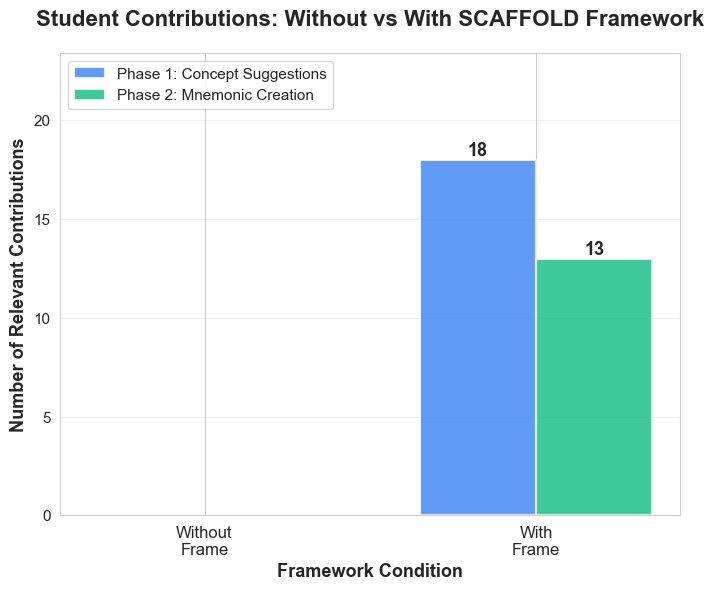

In [42]:
# Visualization: Student contributions by phase and framework condition
fig, ax = plt.subplots(figsize=(8, 6))

# Data for grouped bar chart
conditions = ['Without\nFrame', 'With\nFrame']
phase1_data = [0, total_phase1]  # Phase 1: 0 without, actual count with
phase2_data = [0, total_phase2]  # Phase 2: 0 without, actual count with

x = np.arange(len(conditions))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, phase1_data, width, label='Phase 1: Concept Suggestions', 
               color='#3b82f6', alpha=0.8, linewidth=1.5)
bars2 = ax.bar(x + width/2, phase2_data, width, label='Phase 2: Mnemonic Creation', 
               color='#10b981', alpha=0.8, linewidth=1.5)

ax.set_title('Student Contributions: Without vs With SCAFFOLD Framework', 
             fontweight='bold', fontsize=16, pad=20)
ax.set_ylabel('Number of Relevant Contributions', fontsize=13, fontweight='bold')
ax.set_xlabel('Framework Condition', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=12)
ax.set_ylim(0, max(total_phase1, total_phase2) * 1.3)
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=13, fontweight='bold')

# Add description (using dynamically computed values from merged data)
n_students_for_plot = %R n_students_t2
ax.text(0.5, -0.18, 
        f'Sample: {int(n_students_for_plot)} students across {n_groups_contrib} groups',
        transform=ax.transAxes, ha='center', fontsize=11, style='italic')

plt.tight_layout()
plt.show()

print(f"\n✓ With SCAFFOLD: {int(total_phase1 + total_phase2)} relevant contributions")
print("✗ Without SCAFFOLD: Students were completely passive (0 contributions)")

---

# Finding 2: More Balanced Turn-Taking with SCAFFOLD

**Research Question 2:** To what extent did the frame balance turns between students?


In [ ]:
# Function to calculate Gini Coefficient (Balance Score)
# 
# Formula (G', without self-pairing): G = Σ(2i - n - 1) * x_i / (2 * X̄ * n * (n-1))
# where:
#   x_i = sorted values (ascending order)
#   i = rank index (1 to n)
#   n = number of values
#   X̄ = mean of values
# 
# Range: 0 (perfect equality) to 1 (maximum inequality)
# Lower Gini = More balanced turn distribution
#
# This version excludes self-pairings and is more appropriate for small samples.
#
# Reference: Dixon, P. M., Weiner, J., Mitchell-Olds, T., & Woodley, R. (1987). 
#            Bootstrapping the Gini Coefficient of Inequality. Ecology, 68(5), 1548–1551. 
#            https://doi.org/10.2307/1939238
#      
#
def gini(list_of_values):
    values = np.array(list_of_values)
    values = values[~np.isnan(values)] # Remove NA
    if len(values) == 0 or sum(values) == 0:
        return np.nan
    sorted_values = np.sort(values)
    n = len(values)
    sum_val = np.sum(sorted_values)
    index = np.arange(1, n + 1)
    # G' formula (without self-pairing): G = Σ(2i-n-1)*x_i / (2*Σx_i*(n-1))
    return (np.sum((2 * index - n - 1) * sorted_values)) / (2 * sum_val * (n - 1))

# Load the BuildbotAnalysis data for turn distribution
df_analysis = pd.read_csv(data_path / 'BuildbotAnalysis - LLM analysis.csv', skiprows=1)

# 1. Select the turn columns for each student
s_cols_no = ['No Frame: student 1', 'No Frame: student 2', 'No Frame: student 3']
s_cols_with = ['With Frame: student 1', 'With Frame: student 2', 'With Frame: student 3']

# 2. Calculate Balance Scores for each condition
df_analysis['balance_no_frame'] = df_analysis[s_cols_no].apply(lambda x: gini(x), axis=1)
df_analysis['balance_with_frame'] = df_analysis[s_cols_with].apply(lambda x: gini(x), axis=1)

# Drop rows where we don't have comparison data
df_balance = df_analysis[['Group', 'balance_no_frame', 'balance_with_frame']].dropna()

# Calculate Stats for the Graph
mean_no = df_balance['balance_no_frame'].mean()
var_no = df_balance['balance_no_frame'].var()
mean_with = df_balance['balance_with_frame'].mean()
var_with = df_balance['balance_with_frame'].var()

print("\n=== TURN BALANCE (GINI COEFFICIENT) ===\n")
print("Formula (G', without self-pairing): G = Σ(2i - n - 1) * x_i / (2 * Σx_i * (n-1))")
print("where:")
print("  x_i = sorted values (ascending order)")
print("  i = rank index (1 to n)")
print("  n = number of values")
print("Range: 0 (perfect equality) to 1 (maximum inequality)")
print("Reference: Dixon et al. (1987), Ecology, 68(5), 1548-1551\n")
print(f"Without Frame: G_mean = {mean_no:.2f}, G_var = {var_no:.3f}")
print(f"With Frame: G_mean = {mean_with:.2f}, G_var = {var_with:.3f}")
print(f"\nLower Gini = More balanced turn distribution")


=== TURN BALANCE (GINI COEFFICIENT) ===

Formula (G', without self-pairing): G = Σ(2i - n - 1) * x_i / (2 * Σx_i * (n-1))
where:
  x_i = sorted values (ascending order)
  i = rank index (1 to n)
  n = number of values
Range: 0 (perfect equality) to 1 (maximum inequality)
Reference: Dixon et al. (1987), Ecology, 68(5), 1548-1551

Without Frame: G_mean = 0.28, G_var = 0.046
With Frame: G_mean = 0.15, G_var = 0.008

Lower Gini = More balanced turn distribution


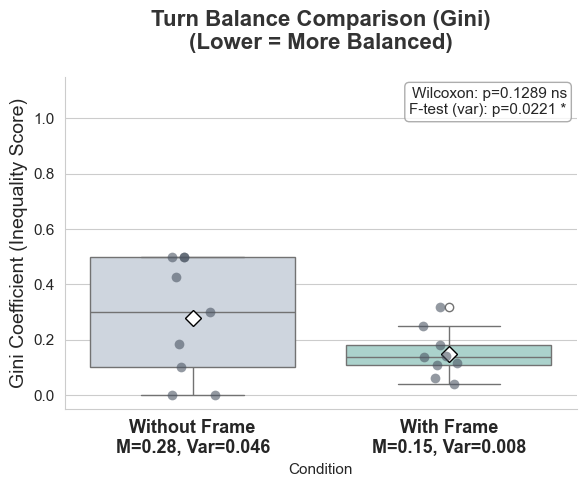


=== WILCOXON SIGNED-RANK TEST (Central Tendency) ===

Statistic: 9.00
p-value: 0.1289

✗ No significant difference in turn balance (p >= 0.05)

=== F-TEST FOR EQUALITY OF VARIANCES (Reliability) ===

Variance Without Frame: 0.0458
Variance With Frame: 0.0078
F-statistic: 5.84
p-value: 0.0221

✓ Significant difference in variance (p < 0.05)
  → Frame condition shows more consistent turn balance


In [ ]:
# Visualization: Gini Coefficient Comparison
from scipy.stats import wilcoxon

plt.figure(figsize=(6, 5))
color_baseline = "#CBD5E1" # Pastel Grey
color_frame    = "#A5D8D0" # Soft Aqua

# Reshape for plotting
df_plot = df_balance.melt(id_vars='Group', var_name='Condition', value_name='Gini')
df_plot['Condition'] = df_plot['Condition'].map({
    'balance_no_frame': 'Without Frame', 
    'balance_with_frame': 'With Frame'
})

# Create boxplot showing the mean as a white diamond
ax = sns.boxplot(data=df_plot, x='Condition', y='Gini', 
                 palette=[color_baseline, color_frame],
                 showmeans=True,
                 meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"},
                 legend=False)

sns.stripplot(data=df_plot, x='Condition', y='Gini', color='#4B5563', alpha=0.6, size=7)

# Update X-axis labels to include Mean and Variance
plt.xticks(ticks=[0, 1], labels=[
    f"Without Frame\nM={mean_no:.2f}, Var={var_no:.3f}",
    f"With Frame\nM={mean_with:.2f}, Var={var_with:.3f}"
], fontsize=13, fontweight='bold')

plt.title("Turn Balance Comparison (Gini)\n(Lower = More Balanced)", fontweight='bold', fontsize=16, pad=20, color='#333333')
plt.ylabel("Gini Coefficient (Inequality Score)", fontsize=14)
plt.ylim(-0.05, 1.15)

# Calculate statistical tests for annotation
stat_w, p_w = wilcoxon(df_balance['balance_no_frame'], df_balance['balance_with_frame'])
var_no_temp = df_balance['balance_no_frame'].var()
var_with_temp = df_balance['balance_with_frame'].var()
n_no_temp = len(df_balance['balance_no_frame'])
n_with_temp = len(df_balance['balance_with_frame'])
F_stat_temp = var_no_temp / var_with_temp if var_no_temp > var_with_temp else var_with_temp / var_no_temp
df1_temp = n_no_temp - 1 if var_no_temp > var_with_temp else n_with_temp - 1
df2_temp = n_with_temp - 1 if var_no_temp > var_with_temp else n_no_temp - 1
from scipy.stats import f as f_dist
p_f = 2 * (1 - f_dist.cdf(F_stat_temp, df1_temp, df2_temp))

# Add statistical test results as text annotation on graph
sig_wilcox = '**' if p_w < 0.01 else '*' if p_w < 0.05 else 'ns'
sig_f = '**' if p_f < 0.01 else '*' if p_f < 0.05 else 'ns'
stats_text = f"Wilcoxon: p={p_w:.4f} {sig_wilcox}\nF-test (var): p={p_f:.4f} {sig_f}"
plt.text(0.98, 0.97, stats_text, transform=ax.transAxes,
         fontsize=11, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#999999'))

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Statistical Testing
# 1. Wilcoxon test for difference in central tendency (median)
stat_w, p_w = wilcoxon(df_balance['balance_no_frame'], df_balance['balance_with_frame'])
print(f"\n=== WILCOXON SIGNED-RANK TEST (Central Tendency) ===\n")
print(f"Statistic: {stat_w:.2f}")
print(f"p-value: {p_w:.4f}")
if p_w < 0.05:
    print("\n✓ Significant difference in turn balance (p < 0.05)")
else:
    print("\n✗ No significant difference in turn balance (p >= 0.05)")

# 2. F-test for difference in variance (reliability/consistency)
var_no = df_balance['balance_no_frame'].var()
var_with = df_balance['balance_with_frame'].var()
n_no = len(df_balance['balance_no_frame'])
n_with = len(df_balance['balance_with_frame'])

# F-statistic: ratio of variances (larger/smaller)
F_stat = var_no / var_with if var_no > var_with else var_with / var_no
df1 = n_no - 1 if var_no > var_with else n_with - 1
df2 = n_with - 1 if var_no > var_with else n_no - 1

from scipy.stats import f
p_f = 2 * (1 - f.cdf(F_stat, df1, df2))  # Two-tailed test

print(f"\n=== F-TEST FOR EQUALITY OF VARIANCES (Reliability) ===\n")
print(f"Variance Without Frame: {var_no:.4f}")
print(f"Variance With Frame: {var_with:.4f}")
print(f"F-statistic: {F_stat:.2f}")
print(f"p-value: {p_f:.4f}")
if p_f < 0.05:
    print("\n✓ Significant difference in variance (p < 0.05)")
    print("  → Frame condition shows more consistent turn balance")
else:
    print("\n✗ No significant difference in variance (p >= 0.05)")

---

# Finding 3: More Active Students Show Higher Post-Test Knowledge Scores

**Research Question 1:** To what extent did the frame support children's short-term and long-term learning?

## Analysis: Co-creation Level → Knowledge Scores (T7 and T8)

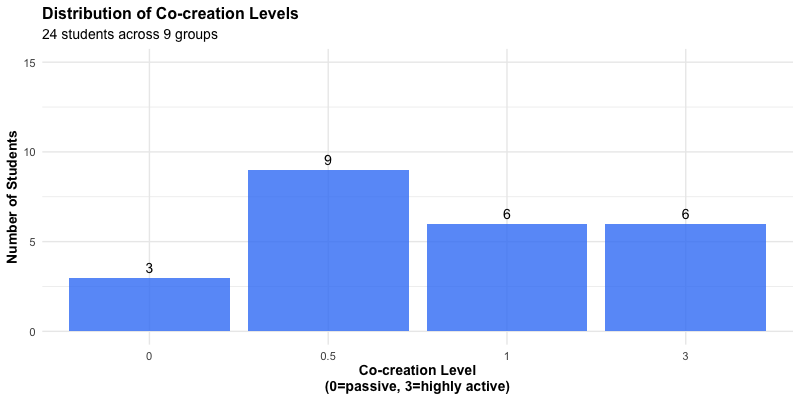

In [50]:
%%R -w 800 -h 400 --units px

# Visualize co-creation level distribution
df_t2 <- df_scored %>% filter(Timepoint == "T2")

ggplot(df_t2, aes(x = factor(Cocreation_Level))) +
  geom_bar(fill = "#3b82f6", alpha = 0.8) +
  geom_text(stat = 'count', aes(label = after_stat(count)), vjust = -0.5, size = 5) +
  labs(
    title = "Distribution of Co-creation Levels",
    subtitle = "24 students across 9 groups",
    x = "Co-creation Level\n(0=passive, 3=highly active)",
    y = "Number of Students"
  ) +
  scale_y_continuous(limits = c(0, 15)) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    axis.title = element_text(face = "bold")
  )

### Combined Model for Short-term and Long-term Learning

This analysis combines Model 1 (T1→T2, immediate post-test) and Model 2 (T1→T3, delayed post-test) into a single mixed-effects model. By reshaping the data to long format with two rows per participant (one for T2, one for T3), we can:

1. Include **Participant ID as a random effect** (nested within Group)
2. Test the **interaction between co-creation and timepoint** (immediate vs. delayed)
3. Control for **prior knowledge** (T1 baseline)

**Model specification:**
```
Knowledge_Score ~ T1_knowledge + co_creation * timepoint + (1 | Participant_ID)
```

**Note:** We use `score10q` (10 questions) as the outcome since it's available at both T2 and T3.

In [ ]:
%%R

# Reshape data to long format for combined analysis
# Each participant has two rows: one for T2 (immediate) and one for T3 (delayed)

# First, get T1 baseline scores for each participant
df_t1_baseline <- df_scored %>%
  filter(Timepoint == "T1") %>%
  select(Student_ID, T1_knowledge = score2q, Group_factor, Cocreation_Level)

# Get T2 and T3 scores
df_long <- df_scored %>%
  filter(Timepoint %in% c("T2", "T3")) %>%
  select(Student_ID, Group_factor, Timepoint, Knowledge_Score = score10q, Cocreation_Level) %>%
  # Join with T1 baseline
  left_join(df_t1_baseline %>% select(Student_ID, T1_knowledge), by = "Student_ID") %>%
  # Create timepoint factor (T2 = immediate, T3 = delayed)
  mutate(
    timepoint = factor(Timepoint, levels = c("T2", "T3"), labels = c("Immediate", "Delayed")),
    Participant_ID = Student_ID,
    Group_ID = Group_factor
  ) %>%
  # Remove rows with missing values
  filter(!is.na(Knowledge_Score), !is.na(T1_knowledge), !is.na(Cocreation_Level))

cat("Data reshaped to long format:\n")
cat(sprintf("  Total observations: %d\n", nrow(df_long)))
cat(sprintf("  Participants: %d\n", n_distinct(df_long$Participant_ID)))
cat(sprintf("  Groups: %d\n", n_distinct(df_long$Group_ID)))
cat(sprintf("  Timepoints per participant: %.2f\n\n", 
            nrow(df_long) / n_distinct(df_long$Participant_ID)))

# Show structure
head(df_long %>% arrange(Participant_ID, timepoint), 10)

Data reshaped to long format:
  Total observations: 46
  Participants: 25
  Groups: 9
  Timepoints per participant: 1.84

   Student_ID Group_factor Timepoint Knowledge_Score Cocreation_Level
1           3            2        T2               9              3.0
2           3            2        T3               7              3.0
3           4            3        T2               4              1.0
4           4            3        T3               0              1.0
5           5            4        T2               6              1.0
6           5            4        T3               7              1.0
7           6            3        T2               4              1.0
8           7            4        T2               7              1.0
9           9            5        T2               7              0.5
10          9            5        T3               4              0.5
   T1_knowledge timepoint Participant_ID Group_ID
1             0 Immediate              3        2
2       

In [ ]:
%%R

# Fit combined mixed-effects model
# Start with full model including nested random effects

cat("\n=== COMBINED MODEL: Short-term and Long-term Learning ===\n\n")

# Attempt full model with nested random effects
cat("Attempting full model: Knowledge_Score ~ T1_knowledge + Cocreation_Level * timepoint + (1 | Group_ID / Participant_ID)\n\n")

model_combined_full <- tryCatch({
  lmer(Knowledge_Score ~ T1_knowledge + Cocreation_Level * timepoint + 
         (1 | Participant_ID), 
       data = df_long,
       REML = TRUE)
}, warning = function(w) {
  if (grepl("singular", w$message, ignore.case = TRUE)) {
    cat("⚠ Singularity warning detected in full model\n")
    cat("Simplifying: Removing Group_ID random effect\n\n")
    return(NULL)
  }
  return(NULL)
})

# If singularity, simplify by removing Group random effect
if (is.null(model_combined_full)) {
  cat("Fitting simplified model: Knowledge_Score ~ T1_knowledge + Cocreation_Level * timepoint + (1 | Participant_ID)\n\n")
  
  model_combined <- lmer(Knowledge_Score ~ T1_knowledge + Cocreation_Level * timepoint + 
                           (1 | Participant_ID), 
                         data = df_long,
                         REML = TRUE)
  
  cat("✓ Simplified model converged successfully\n\n")
} else {
  model_combined <- model_combined_full
  cat("✓ Full model converged successfully\n\n")
}

# Display model summary
summary(model_combined)


=== COMBINED MODEL: Short-term and Long-term Learning ===

Attempting full model: Knowledge_Score ~ T1_knowledge + Cocreation_Level * timepoint + (1 | Group_ID / Participant_ID)

✓ Full model converged successfully

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: Knowledge_Score ~ T1_knowledge + Cocreation_Level * timepoint +  
    (1 | Participant_ID)
   Data: df_long

REML criterion at convergence: 179.9

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.4105 -0.3819  0.1047  0.4330  1.4944 

Random effects:
 Groups         Name        Variance Std.Dev.
 Participant_ID (Intercept) 1.615    1.271   
 Residual                   1.967    1.403   
Number of obs: 46, groups:  Participant_ID, 25

Fixed effects:
                                  Estimate Std. Error      df t value Pr(>|t|)
(Intercept)                         4.8703     0.6063 32.8662   8.033 2.96e-09
T1_knowledge                       -0.1503     0.4790 23.3244  -

#### Model Diagnostics

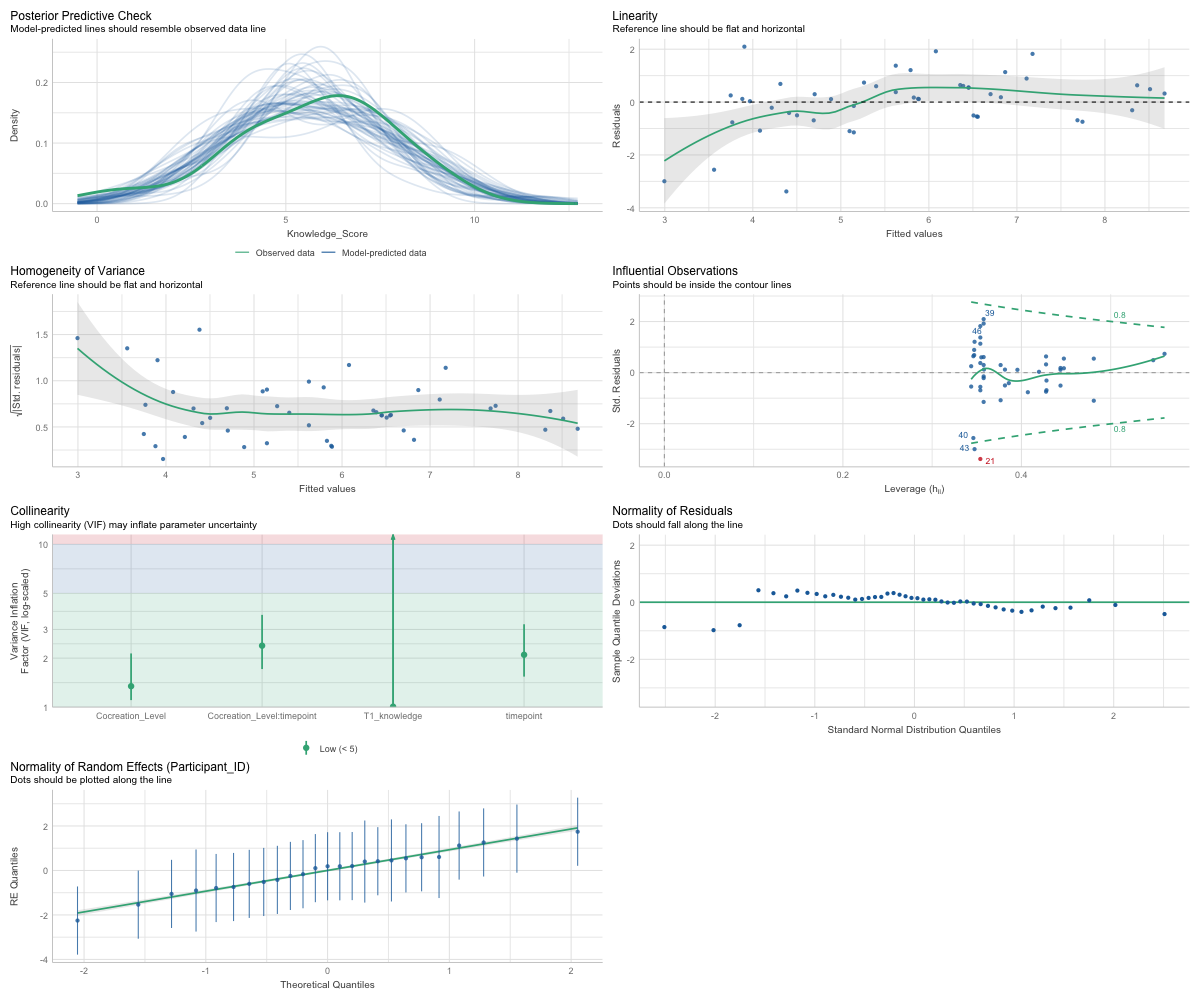

In [52]:
%%R -w 1200 -h 1000 --units px

# Comprehensive assumption checks
check_model(model_combined, panel = TRUE)


=== MODEL DIAGNOSTICS ===



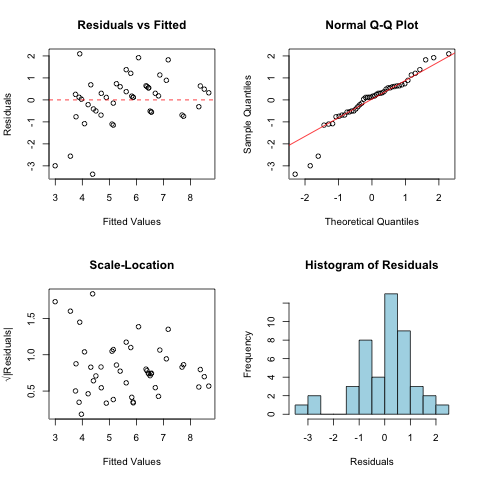

In [ ]:
%%R

# Model diagnostics

cat("\n=== MODEL DIAGNOSTICS ===\n\n")

# Check assumptions
par(mfrow = c(2, 2))

# 1. Residuals vs Fitted
plot(fitted(model_combined), residuals(model_combined),
     xlab = "Fitted Values", ylab = "Residuals",
     main = "Residuals vs Fitted")
abline(h = 0, col = "red", lty = 2)

# 2. Q-Q plot
qqnorm(residuals(model_combined), main = "Normal Q-Q Plot")
qqline(residuals(model_combined), col = "red")

# 3. Scale-Location
plot(fitted(model_combined), sqrt(abs(residuals(model_combined))),
     xlab = "Fitted Values", ylab = "√|Residuals|",
     main = "Scale-Location")

# 4. Residuals histogram
hist(residuals(model_combined), breaks = 15,
     xlab = "Residuals", main = "Histogram of Residuals",
     col = "lightblue")

par(mfrow = c(1, 1))


✓ Visualization complete


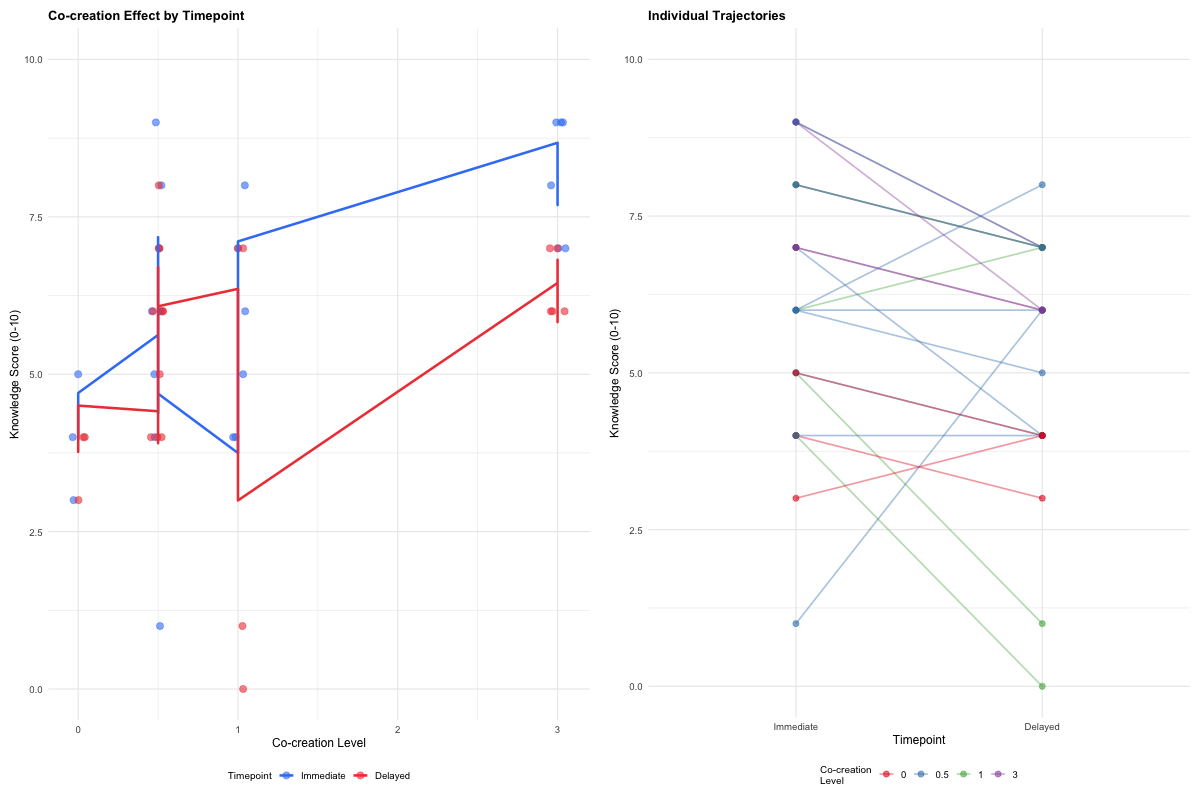

In [51]:
%%R -w 1200 -h 800 --units px

# Visualize the combined model results

# Predicted values for visualization
df_long$predicted <- fitted(model_combined)

# Plot 1: Observed vs Predicted by Timepoint
p1 <- ggplot(df_long, aes(x = Cocreation_Level, y = Knowledge_Score, color = timepoint)) +
  geom_point(alpha = 0.6, size = 3, position = position_jitter(width = 0.05, height = 0)) +
  geom_line(aes(y = predicted, group = timepoint), size = 1.2) +
  scale_color_manual(values = c("Immediate" = "#3b82f6", "Delayed" = "#ef4444"),
                     name = "Timepoint") +
  labs(
    title = "Co-creation Effect by Timepoint",
    x = "Co-creation Level",
    y = "Knowledge Score (0-10)"
  ) +
  ylim(0, 10) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 13),
    legend.position = "bottom",
    legend.title = element_text(size = 10),
    plot.margin = margin(10, 10, 10, 10)
  )

# Plot 2: Individual trajectories
p2 <- ggplot(df_long, aes(x = timepoint, y = Knowledge_Score, group = Participant_ID)) +
  geom_line(aes(color = factor(Cocreation_Level)), alpha = 0.4, size = 0.8) +
  geom_point(aes(color = factor(Cocreation_Level)), alpha = 0.6, size = 2.5) +
  scale_color_brewer(palette = "Set1", name = "Co-creation\nLevel") +
  labs(
    title = "Individual Trajectories",
    x = "Timepoint",
    y = "Knowledge Score (0-10)"
  ) +
  ylim(0, 10) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 13),
    legend.position = "bottom",
    legend.title = element_text(size = 10),
    plot.margin = margin(10, 10, 10, 10)
  )

gridExtra::grid.arrange(p1, p2, ncol = 2)

cat("\n✓ Visualization complete\n")

## Exploratory analysis in relation to pre-registration

### Model 1: Co-creation → Immediate Post-Test (T2)

**Model:** Mixed-effects model `score10q_T7 ~ Co-creation_Level + (1|Group)`

In [ ]:
%%R

# Model 1: Co-creation predicts T2 knowledge (immediate post-test, 10 questions)
df_t2 <- df_scored %>% filter(Timepoint == "T2")

# Mixed-effects model with random intercept for Group
model1_lmer <- lmer(score10q ~ Cocreation_Level + (1|Group_factor), data = df_t2)

cat("\n=== MODEL 1: Mixed-Effects - Co-creation → T2 Knowledge (10 questions) ===\n\n")
print(summary(model1_lmer))

# Extract key statistics
beta_t2 <- fixef(model1_lmer)["Cocreation_Level"]
coef_table <- summary(model1_lmer)$coefficients
p_val_t2 <- coef_table["Cocreation_Level", "Pr(>|t|)"]

cat("\n--- Interpretation ---\n")
cat(sprintf("Fixed Effect (β): %.3f\n", beta_t2))
cat(sprintf("p-value: %.4f\n", p_val_t2))

if (p_val_t2 < 0.05) {
  cat("\n✓ SIGNIFICANT: Higher co-creation predicts better T2 knowledge\n")
  cat(sprintf("  Each level increase in co-creation → +%.2f points (%.0f%% improvement)\n", 
              beta_t2, beta_t2/10*100))
} else {
  cat("\n× NOT SIGNIFICANT at α=0.05\n")
}

# Simple correlation with p-value
cat("\n--- Correlation Analysis ---\n")
cor_test_t2 <- cor.test(df_t2$Cocreation_Level, df_t2$score10q, method = "pearson")
cat(sprintf("Pearson correlation: r = %.3f, p = %.4f\n", 
            cor_test_t2$estimate, cor_test_t2$p.value))


=== MODEL 1: Mixed-Effects - Co-creation → T2 Knowledge (10 questions) ===

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: score10q ~ Cocreation_Level + (1 | Group_factor)
   Data: df_t2

REML criterion at convergence: 93.6

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.47612 -0.68164  0.09132  0.45945  2.08823 

Random effects:
 Groups       Name        Variance Std.Dev.
 Group_factor (Intercept) 0.000    0.000   
 Residual                 3.072    1.753   
Number of obs: 24, groups:  Group_factor, 9

Fixed effects:
                 Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)        4.7690     0.5296 22.0000   9.004 7.85e-09 ***
Cocreation_Level   1.1419     0.3289 22.0000   3.472  0.00216 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
Cocretn_Lvl -0.737
optimizer (nloptwrap) convergence code: 0 (OK)
boundary (singular) fit: 

boundary (singular) fit: see help('isSingular')


#### Model 1 Diagnostics

In [ ]:
%%R -w 1200 -h 1000 --units px

# Model performance
cat("\nModel Performance:\n")
performance::icc(model1_lmer)
performance::r2(model1_lmer)


Model Performance:
Random effect variances not available. Returned R2 does not account for random effects.
# R2 for Mixed Models

  Conditional R2: NA
     Marginal R2: 0.344


De plus : Messages d'avis :
1: Can't compute random effect variances. Some variance components equal
  zero. Your model may suffer from singularity (see `?lme4::isSingular`
  and `?performance::check_singularity`).
  Decrease the `tolerance` level to force the calculation of random effect
  variances, or impose priors on your random effects parameters (using
  packages like `brms` or `glmmTMB`). 
2: Can't compute random effect variances. Some variance components equal
  zero. Your model may suffer from singularity (see `?lme4::isSingular`
  and `?performance::check_singularity`).
  Decrease the `tolerance` level to force the calculation of random effect
  variances, or impose priors on your random effects parameters (using
  packages like `brms` or `glmmTMB`). 


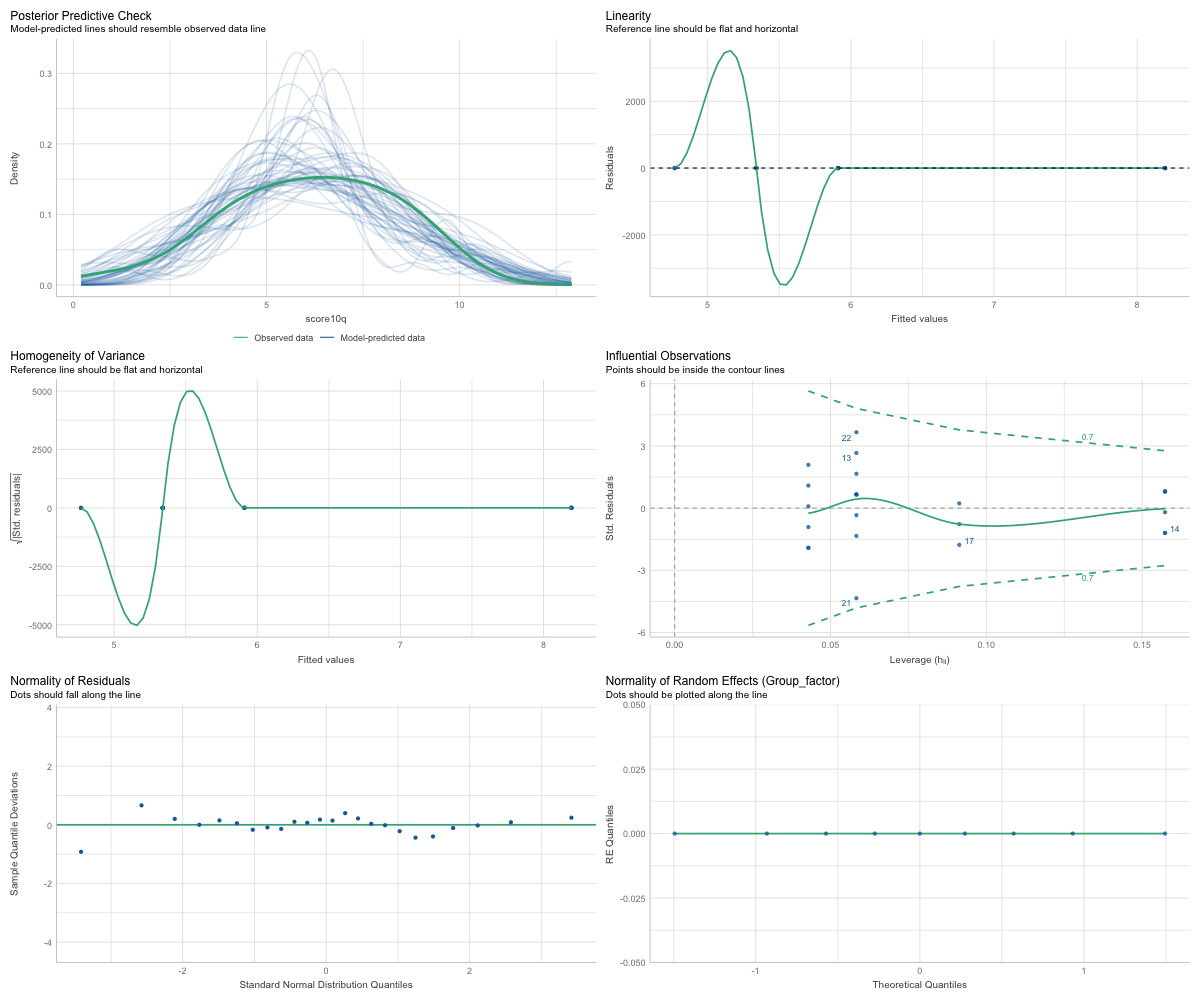

In [ ]:
%%R -w 1200 -h 1000 --units px

# Comprehensive assumption checks
check_model(model1_lmer, panel = TRUE)

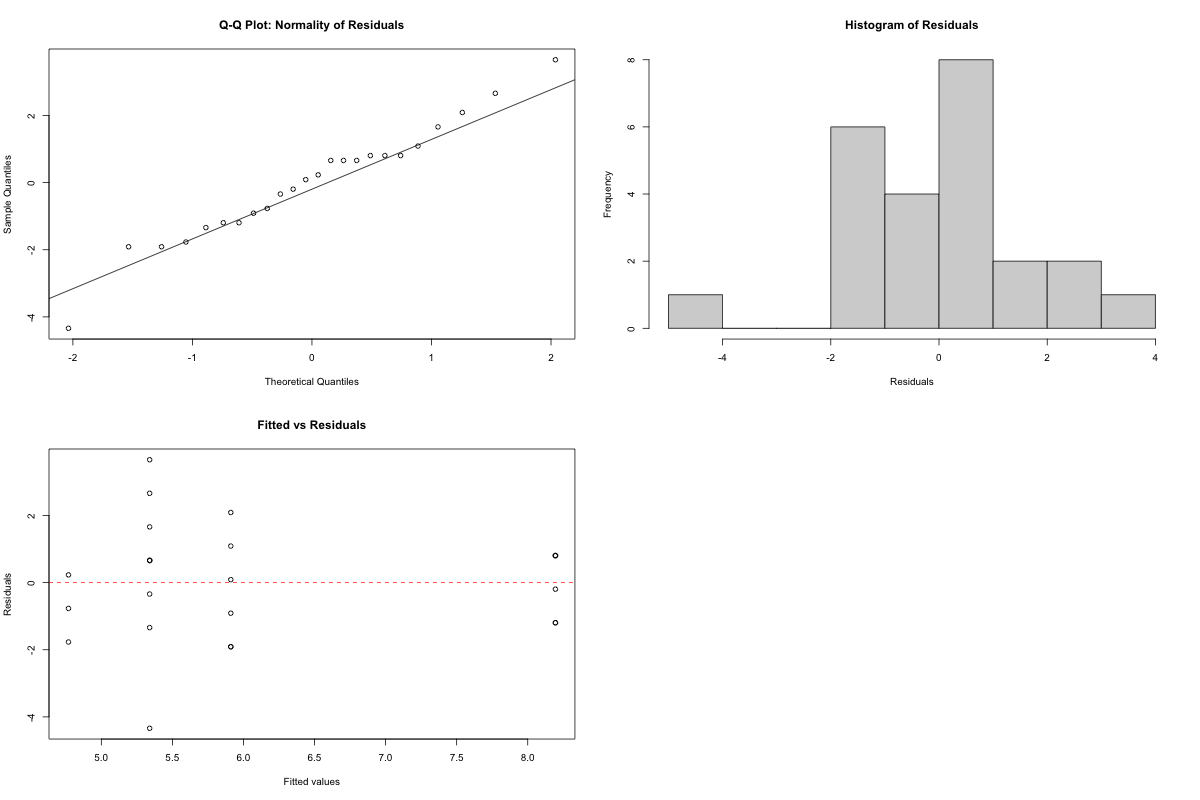

In [ ]:
%%R -w 1200 -h 800 --units px

# Additional diagnostic plots
par(mfrow = c(2, 2))
plot(model1_lmer, main = "Model 1: Residuals vs Fitted")
qqnorm(resid(model1_lmer), main = "Q-Q Plot: Normality of Residuals")
qqline(resid(model1_lmer))
hist(resid(model1_lmer), main = "Histogram of Residuals", xlab = "Residuals", breaks = 10)
plot(fitted(model1_lmer), resid(model1_lmer), main = "Fitted vs Residuals", 
     xlab = "Fitted values", ylab = "Residuals")
abline(h = 0, lty = 2, col = "red")
par(mfrow = c(1, 1))

### Model 2: Co-creation → Delayed Post-Test (T3)

**Model:** Mixed-effects model `score10q_T8 ~ Co-creation_Level + (1|Group)`

In [ ]:
%%R

# Model 2: Co-creation predicts T3 knowledge (delayed post-test)
df_t3 <- df_scored %>% filter(Timepoint == "T3")

# Mixed-effects model with random intercept for Group
model2_lmer <- lmer(score10q ~ Cocreation_Level + (1|Group_factor), data = df_t3)

cat("\n=== MODEL 2: Mixed-Effects - Co-creation → T3 Knowledge (Delayed, 10 questions) ===\n\n")
print(summary(model2_lmer))

# Extract key statistics
beta_t3 <- fixef(model2_lmer)["Cocreation_Level"]
coef_table_t3 <- summary(model2_lmer)$coefficients
p_val_t3 <- coef_table_t3["Cocreation_Level", "Pr(>|t|)"]

cat("\n--- Interpretation ---\n")
cat(sprintf("Fixed Effect (β): %.3f\n", beta_t3))
cat(sprintf("p-value: %.4f\n", p_val_t3))

if (p_val_t3 < 0.05) {
  cat("\n✓ SIGNIFICANT: Co-creation benefits persist at T3\n")
  cat(sprintf("  Each level increase in co-creation → +%.2f points (%.0f%% improvement)\n", 
              beta_t3, beta_t3/10*100))
} else {
  cat("\n× NOT SIGNIFICANT at α=0.05\n")
  cat("  Co-creation benefits may not fully persist over time\n")
}

# Simple correlation with p-value
cat("\n--- Correlation Analysis ---\n")
cor_test_t3 <- cor.test(df_t3$Cocreation_Level, df_t3$score10q, method = "pearson")
cat(sprintf("Pearson correlation: r = %.3f, p = %.4f\n", 
            cor_test_t3$estimate, cor_test_t3$p.value))


=== MODEL 2: Mixed-Effects - Co-creation → T3 Knowledge (Delayed, 10 questions) ===

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: score10q ~ Cocreation_Level + (1 | Group_factor)
   Data: df_t3

REML criterion at convergence: 94.4

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.65756 -0.42124  0.01982  0.52832  1.54532 

Random effects:
 Groups       Name        Variance Std.Dev.
 Group_factor (Intercept) 0.000    0.000   
 Residual                 3.867    1.967   
Number of obs: 23, groups:  Group_factor, 9

Fixed effects:
                 Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)        4.6958     0.5824 21.0000   8.062 7.27e-08 ***
Cocreation_Level   0.5305     0.3883 21.0000   1.366    0.186    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
Cocretn_Lvl -0.710
optimizer (nloptwrap) convergence code: 0 (OK)
boundary (singul

boundary (singular) fit: see help('isSingular')


#### Model 2 Diagnostics

In [ ]:
%%R -w 1200 -h 1000 --units px

# Model performance
cat("\nModel Performance:\n")
performance::icc(model2_lmer)
performance::r2(model2_lmer)


Model Performance:
Random effect variances not available. Returned R2 does not account for random effects.
# R2 for Mixed Models

  Conditional R2: NA
     Marginal R2: 0.078


De plus : Messages d'avis :
1: Can't compute random effect variances. Some variance components equal
  zero. Your model may suffer from singularity (see `?lme4::isSingular`
  and `?performance::check_singularity`).
  Decrease the `tolerance` level to force the calculation of random effect
  variances, or impose priors on your random effects parameters (using
  packages like `brms` or `glmmTMB`). 
2: Can't compute random effect variances. Some variance components equal
  zero. Your model may suffer from singularity (see `?lme4::isSingular`
  and `?performance::check_singularity`).
  Decrease the `tolerance` level to force the calculation of random effect
  variances, or impose priors on your random effects parameters (using
  packages like `brms` or `glmmTMB`). 


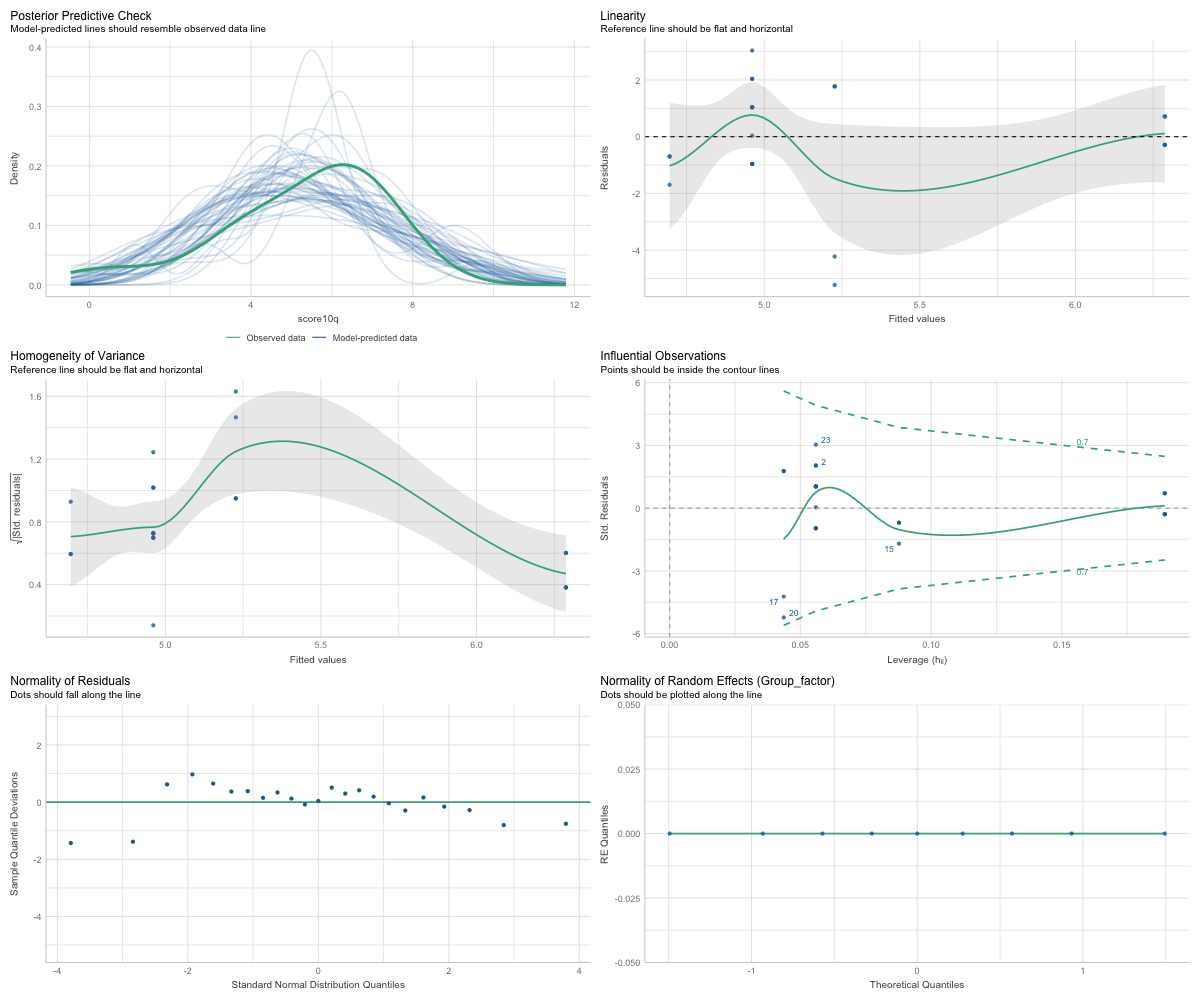

In [ ]:
%%R -w 1200 -h 1000 --units px

# Comprehensive assumption checks
check_model(model2_lmer, panel = TRUE)

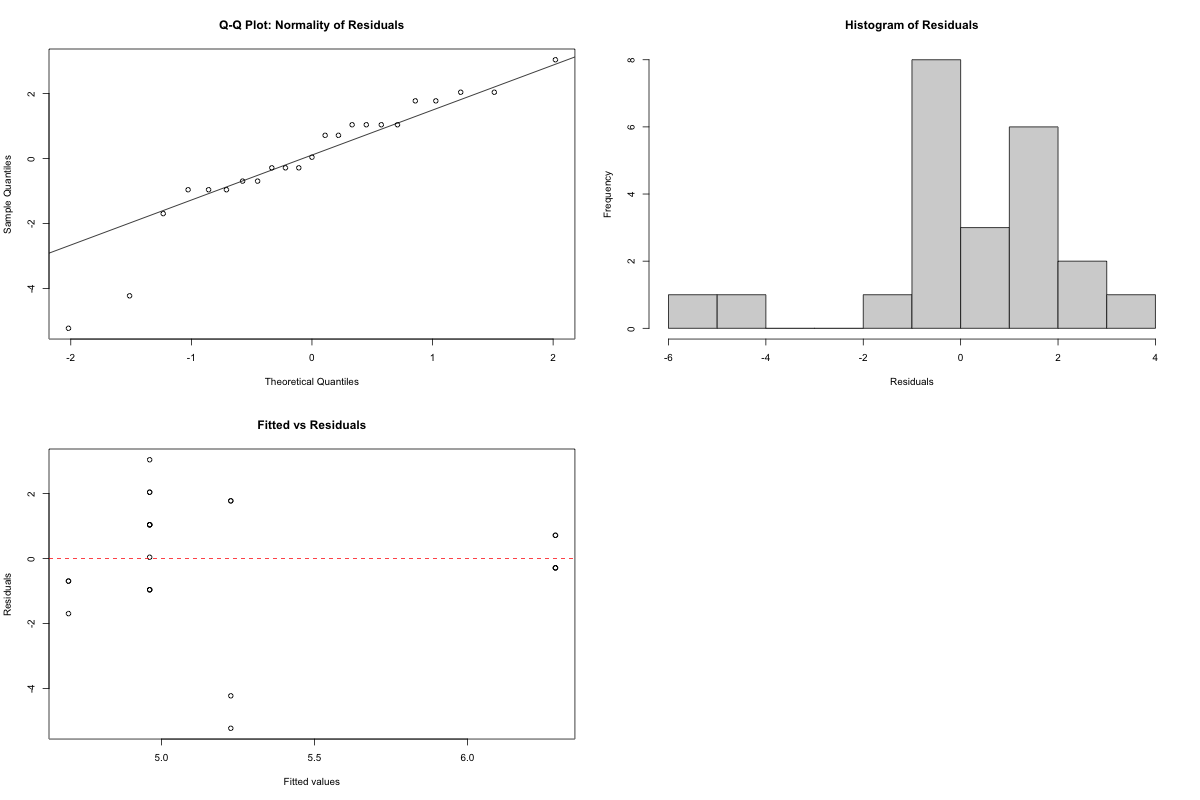

In [ ]:
%%R -w 1200 -h 800 --units px

# Additional diagnostic plots
par(mfrow = c(2, 2))
plot(model2_lmer, main = "Model 2: Residuals vs Fitted")
qqnorm(resid(model2_lmer), main = "Q-Q Plot: Normality of Residuals")
qqline(resid(model2_lmer))
hist(resid(model2_lmer), main = "Histogram of Residuals", xlab = "Residuals", breaks = 10)
plot(fitted(model2_lmer), resid(model2_lmer), main = "Fitted vs Residuals", 
     xlab = "Fitted values", ylab = "Residuals")
abline(h = 0, lty = 2, col = "red")
par(mfrow = c(1, 1))

### Model 1 and 2: Visualisation Finding 2

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


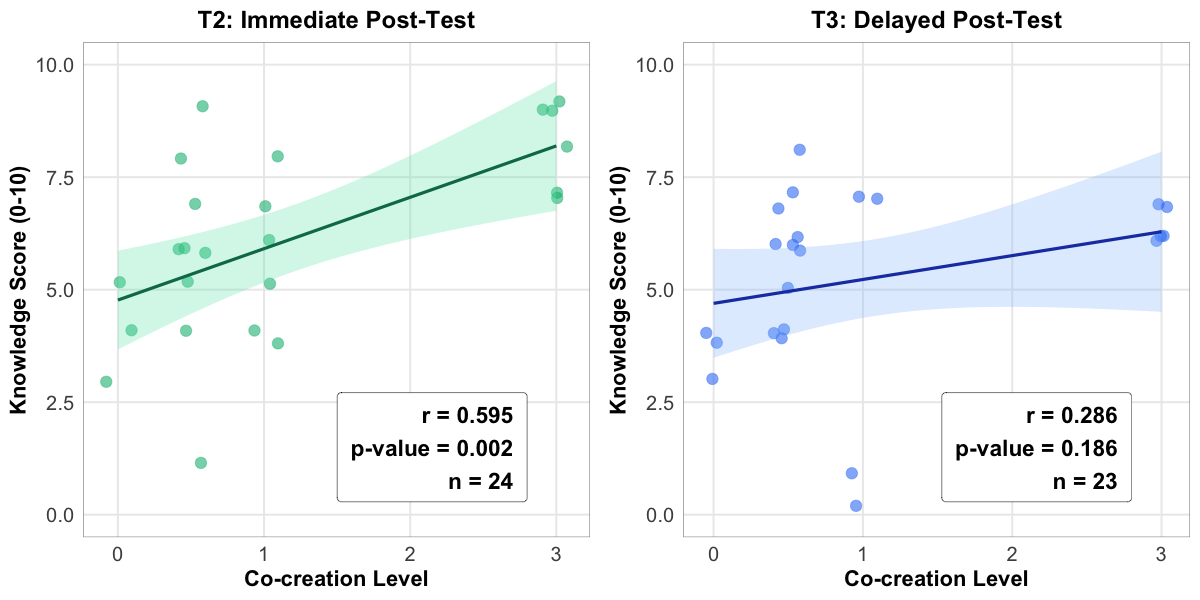

In [ ]:
%%R -w 1200 -h 600 --units px

# Publication-ready visualization: Co-creation vs Knowledge at T2 and T3
library(gridExtra)

df_t2_t3 <- df_scored %>% filter(Timepoint %in% c("T2", "T3"))

# Calculate correlations and p-values for annotations
cor_t2 <- cor.test(df_t2_t3$Cocreation_Level[df_t2_t3$Timepoint == "T2"], 
                   df_t2_t3$score10q[df_t2_t3$Timepoint == "T2"], 
                   method = "pearson")
cor_t3 <- cor.test(df_t2_t3$Cocreation_Level[df_t2_t3$Timepoint == "T3"], 
                   df_t2_t3$score10q[df_t2_t3$Timepoint == "T3"], 
                   method = "pearson")

# Format p-values
p_t2_text <- ifelse(cor_t2$p.value < 0.001, "p-value: < 0.001", 
                    sprintf("p-value = %.3f", cor_t2$p.value))
p_t3_text <- ifelse(cor_t3$p.value < 0.001, "p-value: < 0.001", 
                    sprintf("p-value = %.3f", cor_t3$p.value))

# Create annotation text
annot_t2 <- sprintf("r = %.3f\n%s\nn = %d", 
                    cor_t2$estimate, p_t2_text, 
                    sum(!is.na(df_t2_t3$score10q[df_t2_t3$Timepoint == "T2"])))
annot_t3 <- sprintf("r = %.3f\n%s\nn = %d", 
                    cor_t3$estimate, p_t3_text,
                    sum(!is.na(df_t2_t3$score10q[df_t2_t3$Timepoint == "T3"])))

# Plot T2 (Immediate Post-Test, GREEN)
p1 <- ggplot(df_t2_t3 %>% filter(Timepoint == "T2"), 
             aes(x = Cocreation_Level, y = score10q)) +
  geom_jitter(width = 0.1, height = 0.2, alpha = 0.6, size = 5, color = "#10b981") +
  geom_smooth(method = "lm", se = TRUE, color = "#047857", fill = "#6ee7b7", 
              alpha = 0.3, linewidth = 1.5) +
  annotate("label", x = 2.8, y = 1.5, label = annot_t2, 
           hjust = 1, size = 8, fontface = "bold", 
           fill = "white", label.padding = unit(0.5, "lines")) +
  labs(
    title = "T2: Immediate Post-Test",
    x = "Co-creation Level",
    y = "Knowledge Score (0-10)"
  ) +
  scale_x_continuous(breaks = 0:3) +
  ylim(0, 10) +
  theme_minimal(base_size = 20) +
  theme(
    plot.title = element_text(face = "bold", size = 24, hjust = 0.5),
    axis.title = element_text(face = "bold", size = 22),
    axis.text = element_text(size = 20),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(color = "gray50", fill = NA, linewidth = 0.5)
  )

# Plot T3 (BLUE)
p2 <- ggplot(df_t2_t3 %>% filter(Timepoint == "T3"), 
             aes(x = Cocreation_Level, y = score10q)) +
  geom_jitter(width = 0.1, height = 0.2, alpha = 0.6, size = 5, color = "#3b82f6") +
  geom_smooth(method = "lm", se = TRUE, color = "#1e40af", fill = "#93c5fd", 
              alpha = 0.3, linewidth = 1.5) +
  annotate("label", x = 2.8, y = 1.5, label = annot_t3, 
           hjust = 1, size = 8, fontface = "bold", 
           fill = "white", label.padding = unit(0.5, "lines")) +
  labs(
    title = "T3: Delayed Post-Test",
    x = "Co-creation Level",
    y = "Knowledge Score (0-10)"
  ) +
  scale_x_continuous(breaks = 0:3) +
  ylim(0, 10) +
  theme_minimal(base_size = 20) +
  theme(
    plot.title = element_text(face = "bold", size = 24, hjust = 0.5),
    axis.title = element_text(face = "bold", size = 22),
    axis.text = element_text(size = 20),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(color = "gray50", fill = NA, linewidth = 0.5)
  )

# Combine plots (title embedded in individual plots)
grid.arrange(p1, p2, ncol = 2)

---

**Research Question 4:** To what extent does children's prior knowledge (T1) predict co-creation level?

**Finding:** T1 scores do **not** predict co-creation level, suggesting that engagement was independent of prior ability.

### Model 3: Baseline Knowledge (T1) → Co-creation Level

**Note:** This uses **score2q** (the only measure available at T1).

In [ ]:
%%R

# Aggregate to group level (co-creation is group-level)
df_t1 <- df_scored %>% filter(Timepoint == "T1")

df_t1_group <- df_t1 %>%
  group_by(Group_factor) %>%
  summarise(
    mean_T1_score = mean(score2q, na.rm = TRUE),
    Cocreation_Level = first(Cocreation_Level)
  )

# Simple linear regression (group-level)
model_selection <- lm(Cocreation_Level ~ mean_T1_score, data = df_t1_group)

cat("\n=== MODEL: T1 Knowledge (2q) → Co-creation Level ===\n\n")
print(summary(model_selection))

beta_selection <- coef(model_selection)["mean_T1_score"]
p_selection <- summary(model_selection)$coefficients[2, 4]

cat("\n--- Interpretation ---\n")
if (p_selection < 0.05) {
  cat("⚠ SELECTION EFFECT DETECTED\n")
  cat("  Prior knowledge predicts co-creation level\n")
  cat("  → Caution needed for causal interpretation\n")
} else {
  cat("✓ NO SELECTION EFFECT\n")
  cat("  Prior knowledge does NOT predict co-creation\n")
  cat("  → Supports causal interpretation of co-creation effects\n")
}


=== MODEL: T1 Knowledge (2q) → Co-creation Level ===


Call:
lm(formula = Cocreation_Level ~ mean_T1_score, data = df_t1_group)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.1167 -0.6000 -0.6000 -0.1083  1.8917 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)  
(Intercept)     1.1000     0.5315   2.070   0.0773 .
mean_T1_score   0.0250     0.7973   0.031   0.9759  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.188 on 7 degrees of freedom
Multiple R-squared:  0.0001404,	Adjusted R-squared:  -0.1427 
F-statistic: 0.0009833 on 1 and 7 DF,  p-value: 0.9759


--- Interpretation ---
✓ NO SELECTION EFFECT
  Prior knowledge does NOT predict co-creation
  → Supports causal interpretation of co-creation effects


`geom_smooth()` using formula = 'y ~ x'


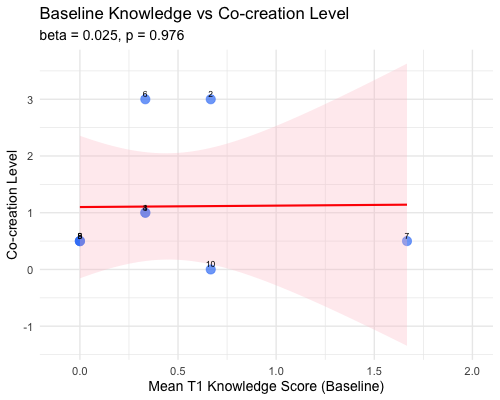

In [ ]:
%%R -w 500 -h 400 --units px

# Visualization
ggplot(df_t1_group, aes(x = mean_T1_score, y = Cocreation_Level)) +
  geom_point(size = 4, alpha = 0.7, color = "#3b82f6") +
  geom_smooth(method = "lm", se = TRUE, color = "red", fill = "pink", alpha = 0.3) +
  geom_text(aes(label = Group_factor), nudge_y = 0.1, size = 3) +
  labs(
    title = "Baseline Knowledge vs Co-creation Level",
    subtitle = sprintf("beta = %.3f, p = %.3f", beta_selection, p_selection),
    x = "Mean T1 Knowledge Score (Baseline)",
    y = "Co-creation Level"
  ) +
  xlim(-0.1, 2) +
  theme_minimal(base_size = 14)

---

# Finding 4: Dramatically Fewer Off-Topic Turns

**Key Result (from Finding 4 analysis above):** 
- **With SCAFFOLD:** ~99% on-topic turns
- **Without SCAFFOLD:** ~62% on-topic turns

This suggests students were more engaged and focused with the framework.

In [54]:
# Load turn-taking data from comparison file
comparison_cols = ['Group', 'Number of Turns in Frame', 'Number of Turns in No Frame',
                   'Out of topic turns  with frame', 'Out of topic turns without Frame']

df_turns = pd.read_csv(data_path / 'BuildbotAnalysis - LLM analysis.csv', 
                       skiprows=1, usecols=comparison_cols)

df_turns = df_turns.dropna(subset=['Group'])
# Remove summary rows like 'Grand Total'
df_turns = df_turns[df_turns['Group'].apply(lambda x: str(x).replace('.', '', 1).isdigit())]
df_turns['Group'] = df_turns['Group'].astype(int)

# Calculate totals
total_turns_frame = df_turns['Number of Turns in Frame'].sum()
total_turns_no_frame = df_turns['Number of Turns in No Frame'].sum()
off_topic_frame = df_turns['Out of topic turns  with frame'].sum()
off_topic_no_frame = df_turns['Out of topic turns without Frame'].sum()

print("\n=== TURN-TAKING STATISTICS ===\n")
print(f"Total turns WITH SCAFFOLD: {total_turns_frame:.0f}")
print(f"Total turns WITHOUT SCAFFOLD: {total_turns_no_frame:.0f}")
print(f"\nOff-topic WITH SCAFFOLD: {off_topic_frame:.0f} ({off_topic_frame/total_turns_frame*100:.1f}%)")
print(f"Off-topic WITHOUT SCAFFOLD: {off_topic_no_frame:.0f} ({off_topic_no_frame/total_turns_no_frame*100:.1f}%)")
print(f"\n✓ On-topic WITH SCAFFOLD: {100 - off_topic_frame/total_turns_frame*100:.0f}%")
print(f"  On-topic WITHOUT SCAFFOLD: {100 - off_topic_no_frame/total_turns_no_frame*100:.0f}%")

# Statistical tests for turn distribution
from scipy.stats import wilcoxon

# Clean data before testing - remove NaN and ensure numeric
df_clean = df_turns.dropna(subset=['Number of Turns in No Frame', 'Number of Turns in Frame',
                                     'Out of topic turns without Frame', 'Out of topic turns  with frame']).copy()

# Convert to numeric if needed
for col in ['Number of Turns in No Frame', 'Number of Turns in Frame', 
            'Out of topic turns without Frame', 'Out of topic turns  with frame']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Remove any rows with NaN after conversion
df_clean = df_clean.dropna()

print(f"\nNote: Analysis includes {len(df_clean)} groups with complete data (1 group excluded due to data loss)")

# Calculate percentages of off-topic turns for each group
df_clean['pct_offtopic_no_frame'] = (df_clean['Out of topic turns without Frame'] / 
                                      df_clean['Number of Turns in No Frame'] * 100)
df_clean['pct_offtopic_frame'] = (df_clean['Out of topic turns  with frame'] / 
                                   df_clean['Number of Turns in Frame'] * 100)

# Run Wilcoxon signed-rank tests (paired, non-parametric test)
stat_turns, p_turns = wilcoxon(df_clean['Number of Turns in No Frame'], 
                                 df_clean['Number of Turns in Frame'],
                                 zero_method='wilcox', alternative='two-sided')
stat_offtopic, p_offtopic = wilcoxon(df_clean['pct_offtopic_no_frame'], 
                                       df_clean['pct_offtopic_frame'],
                                       zero_method='wilcox', alternative='two-sided')

# Print statistical results
print("\n=== STATISTICAL TESTS: TURN DISTRIBUTION ===\n")
print("Total Turns Comparison:")
print(f"  Wilcoxon signed-rank test: W={stat_turns:.2f}, p={p_turns:.4f}")
if p_turns < 0.05:
    print(f"  ✓ Significant difference in total turns (p < 0.05)")
else:
    print(f"  ✗ No significant difference in total turns (p >= 0.05)")

print("\nOff-Topic Turns Comparison:")
print(f"  Wilcoxon signed-rank test: W={stat_offtopic:.2f}, p={p_offtopic:.4f}")
if p_offtopic < 0.05:
    print(f"  ✓ Significant difference in off-topic turns (p < 0.05)")
    print(f"  → Frame condition shows significantly fewer off-topic turns")
else:
    print(f"  ✗ No significant difference in off-topic turns (p >= 0.05)")


=== TURN-TAKING STATISTICS ===

Total turns WITH SCAFFOLD: 104
Total turns WITHOUT SCAFFOLD: 79

Off-topic WITH SCAFFOLD: 1 (1.0%)
Off-topic WITHOUT SCAFFOLD: 30 (38.0%)

✓ On-topic WITH SCAFFOLD: 99%
  On-topic WITHOUT SCAFFOLD: 62%

Note: Analysis includes 9 groups with complete data (1 group excluded due to data loss)

=== STATISTICAL TESTS: TURN DISTRIBUTION ===

Total Turns Comparison:
  Wilcoxon signed-rank test: W=11.50, p=0.2109
  ✗ No significant difference in total turns (p >= 0.05)

Off-Topic Turns Comparison:
  Wilcoxon signed-rank test: W=0.00, p=0.0312
  ✓ Significant difference in off-topic turns (p < 0.05)
  → Frame condition shows significantly fewer off-topic turns


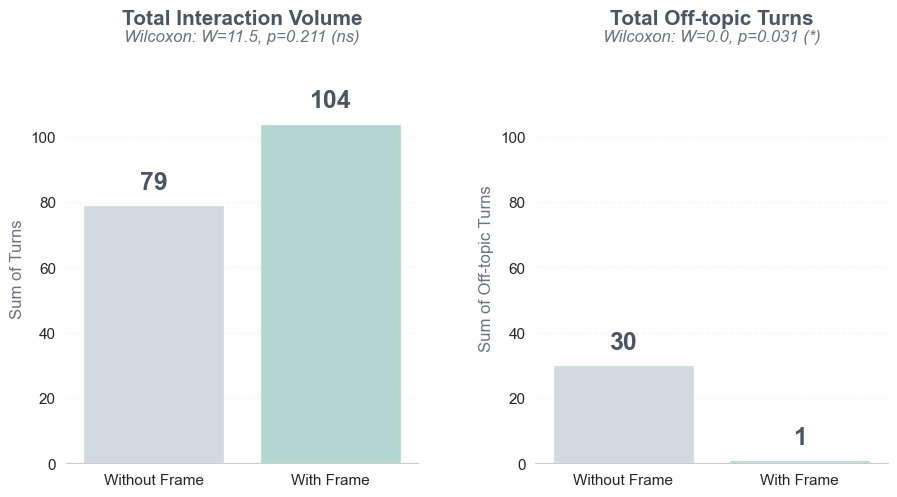

In [ ]:
# --- DESIGNER PALETTE: PASTEL SLATE & SOFT AQUA ---
color_baseline = "#CBD5E1" # Pastel Slate Grey
color_frame    = "#A5D8D0" # Soft Pastel Mint/Aqua (Blue-Green shift)

# Calculate the maximum value across ALL bars to set a uniform scale
all_values = [total_turns_no_frame, total_turns_frame, off_topic_no_frame, off_topic_frame]
max_val = max(all_values)
upper_limit = max_val * 1.15 # Add 15% head room for the numeric labels

# Visualization: Turn distribution comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))

# Subplot 1: Total Number of Turns
turn_categories = ['Without Frame', 'With Frame']
turn_values = [total_turns_no_frame, total_turns_frame]

import seaborn as sns
sns.barplot(x=turn_categories, y=turn_values, hue=turn_categories, 
            palette=[color_baseline, color_frame], ax=ax1, alpha=0.9, legend=False)

ax1.set_title("Total Interaction Volume", fontweight='bold', fontsize=15, pad=35, color='#4B5563')
# Add statistical result as subtitle
sig_symbol_turns = '*' if p_turns < 0.05 else 'ns'
ax1.text(0.5, 1.08, f'Wilcoxon: W={stat_turns:.1f}, p={p_turns:.3f} ({sig_symbol_turns})', 
         transform=ax1.transAxes, ha='center', fontsize=12, color='#6B7280', style='italic')
ax1.set_ylabel("Sum of Turns", fontsize=12, color='#6B7280')
ax1.set_xlabel('')
ax1.set_ylim(0, upper_limit) # Set uniform scale
ax1.yaxis.grid(True, linestyle='--', which='major', color='#F3F4F6', alpha=0.8)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 8), textcoords='offset points', 
                fontweight='bold', fontsize=18, color='#4B5563')


# Subplot 2: Total Number of Off-topic Turns
off_categories = ['Without Frame', 'With Frame']
off_values = [off_topic_no_frame, off_topic_frame]

sns.barplot(x=off_categories, y=off_values, hue=off_categories, 
            palette=[color_baseline, color_frame], ax=ax2, alpha=0.9, legend=False)

ax2.set_title("Total Off-topic Turns", fontweight='bold', fontsize=15, pad=35, color='#4B5563')
# Add statistical result as subtitle
sig_symbol_offtopic = '**' if p_offtopic < 0.01 else ('*' if p_offtopic < 0.05 else 'ns')
ax2.text(0.5, 1.08, f'Wilcoxon: W={stat_offtopic:.1f}, p={p_offtopic:.3f} ({sig_symbol_offtopic})', 
         transform=ax2.transAxes, ha='center', fontsize=12, color='#6B7280', style='italic')
ax2.set_ylabel("Sum of Off-topic Turns", fontsize=12, color='#6B7280')
ax2.set_xlabel('')
ax2.set_ylim(0, upper_limit) # Set uniform scale
ax2.yaxis.grid(True, linestyle='--', which='major', color='#F3F4F6', alpha=0.8)
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 8), textcoords='offset points', 
                fontweight='bold', fontsize=18, color='#4B5563')

plt.tight_layout(pad=4.0)
plt.show()

---

# Finding 5: Students and Teachers Enjoyed the Activity

## Student Feedback (at T2)

Sample size will be computed from the data.

Three dimensions of student experience:
1. **LLM Enjoyment:** How did you like your interaction with Marty? (1-5)
2. **LLM Learning Help:** How much did the conversation help you learn? (1-5)
3. **Perceived Turn Balance:** Did everyone talk to Marty equally? (1-4)

In [ ]:
# Student feedback analysis
df_feedback = df_engagement[df_engagement['Timepoint'] == 'T7'].copy()

feedback_cols = ['LLM_enjoyment', 'LLM_learning', 'LLM_contributions']
df_feedback_clean = df_feedback[feedback_cols].dropna()

print("\n=== STUDENT FEEDBACK (T2) ===\n")
print(f"N = {len(df_feedback_clean)} students\n")
print(df_feedback_clean.describe().round(2))

print("\nMean Ratings:")
print(f"  Enjoyment: {df_feedback_clean['LLM_enjoyment'].mean():.2f}/5.0")
print(f"  Learning Help: {df_feedback_clean['LLM_learning'].mean():.2f}/5.0")
print(f"  Turn Balance: {df_feedback_clean['LLM_contributions'].mean():.2f}/4.0")


=== STUDENT FEEDBACK (T2) ===

N = 26 students

       LLM_enjoyment  LLM_learning  LLM_contributions
count          26.00         26.00              26.00
mean            3.96          3.27               2.73
std             0.92          1.12               0.87
min             2.00          1.00               1.00
25%             4.00          3.00               2.00
50%             4.00          3.00               3.00
75%             4.75          4.00               3.00
max             5.00          5.00               4.00

Mean Ratings:
  Enjoyment: 3.96/5.0
  Learning Help: 3.27/5.0
  Turn Balance: 2.73/4.0


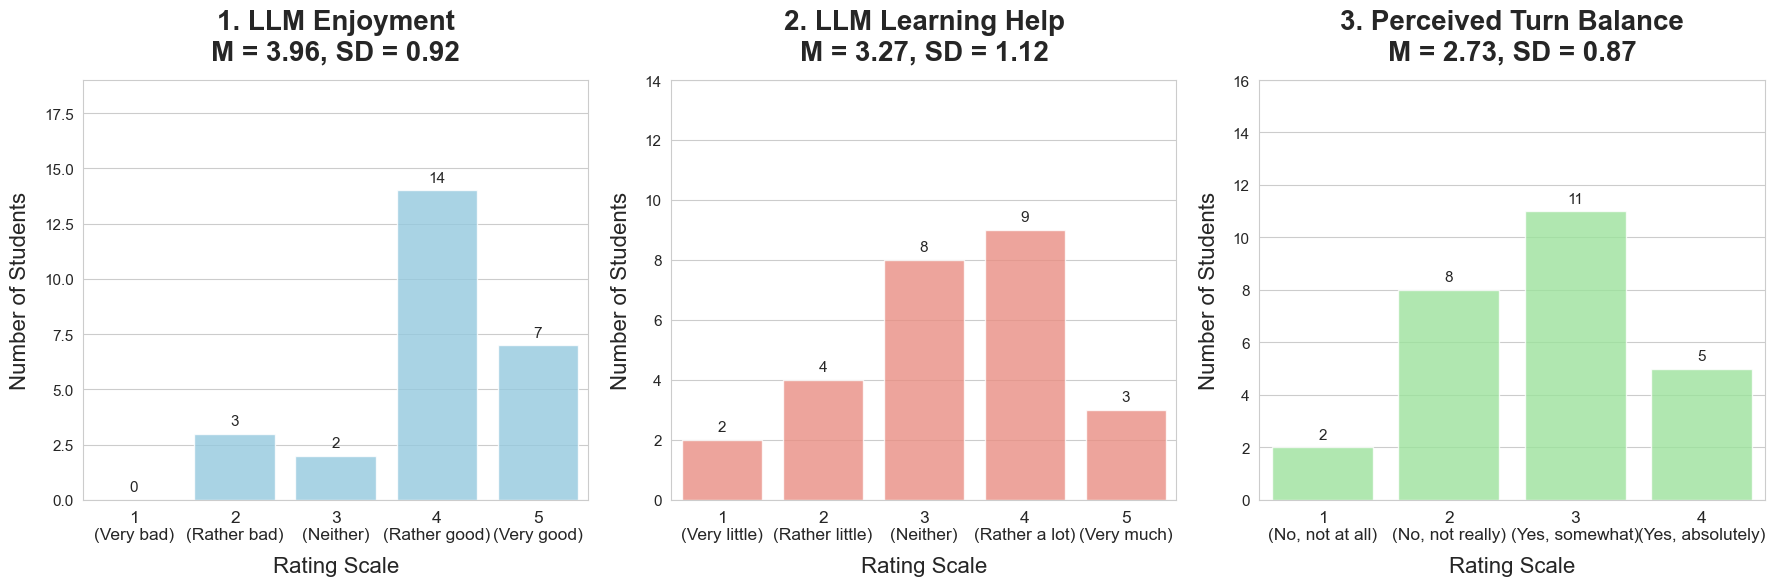

In [ ]:
# Visualization: Student feedback distribution with qualitative labels

# Define qualitative labels for the 3 metrics
enjoyment_labels = {1: 'Very bad', 2: 'Rather bad', 3: 'Neither', 4: 'Rather good', 5: 'Very good'}
learning_labels = {1: 'Very little', 2: 'Rather little', 3: 'Neither', 4: 'Rather a lot', 5: 'Very much'}
contribution_labels = {1: 'No, not at all', 2: 'No, not really', 3: 'Yes, somewhat', 4: 'Yes, absolutely'}

def plot_distribution(data, column, title, labels_map, color, subplot_idx):
    plt.subplot(1, 3, subplot_idx)
    
    # Ensure all scale points are shown, even if they have 0 counts
    possible_values = sorted(labels_map.keys())
    counts = data[column].value_counts().reindex(possible_values).fillna(0)
    
    # Create the bar plot
    ax = sns.barplot(x=counts.index, y=counts.values, color=color, alpha=0.8)
    
    # Calculate mean and standard deviation
    mean_val = data[column].mean()
    sd_val = data[column].std()
    
    # Add title with mean and SD
    plt.title(f'{title}\nM = {mean_val:.2f}, SD = {sd_val:.2f}', 
              fontweight='bold', pad=15, fontsize=20)
    plt.xlabel('Rating Scale', fontsize=16, labelpad=10)
    plt.ylabel('Number of Students', fontsize=16, labelpad=10)
    plt.ylim(0, counts.max() + 5)
    
    # Add count labels on top of each bar
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points')
    
    # Replace numeric ticks with qualitative labels
    plt.xticks(ticks=range(len(possible_values)), 
               labels=[f"{v}\n({labels_map[v]})" for v in possible_values], 
               fontsize=12.5)

# Create the 3-panel figure
plt.figure(figsize=(18, 6))

plot_distribution(df_feedback_clean, 'LLM_enjoyment', '1. LLM Enjoyment', enjoyment_labels, 'skyblue', 1)
plot_distribution(df_feedback_clean, 'LLM_learning', '2. LLM Learning Help', learning_labels, 'salmon', 2)
plot_distribution(df_feedback_clean, 'LLM_contributions', '3. Perceived Turn Balance', contribution_labels, 'lightgreen', 3)

plt.tight_layout()
plt.savefig('llm_interaction_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## Teacher Feedback (at T2)

Sample size will be computed from the data.

Three dimensions of teacher experience with the LLM:
1. **LLM Helpfulness:** Not helpful at all (1) to Very helpful (4)
2. **LLM Ease of Use:** Very difficult (1) to Very easy (5)
3. **LLM Engagement:** Not entertaining at all (1) to Very entertaining (5)

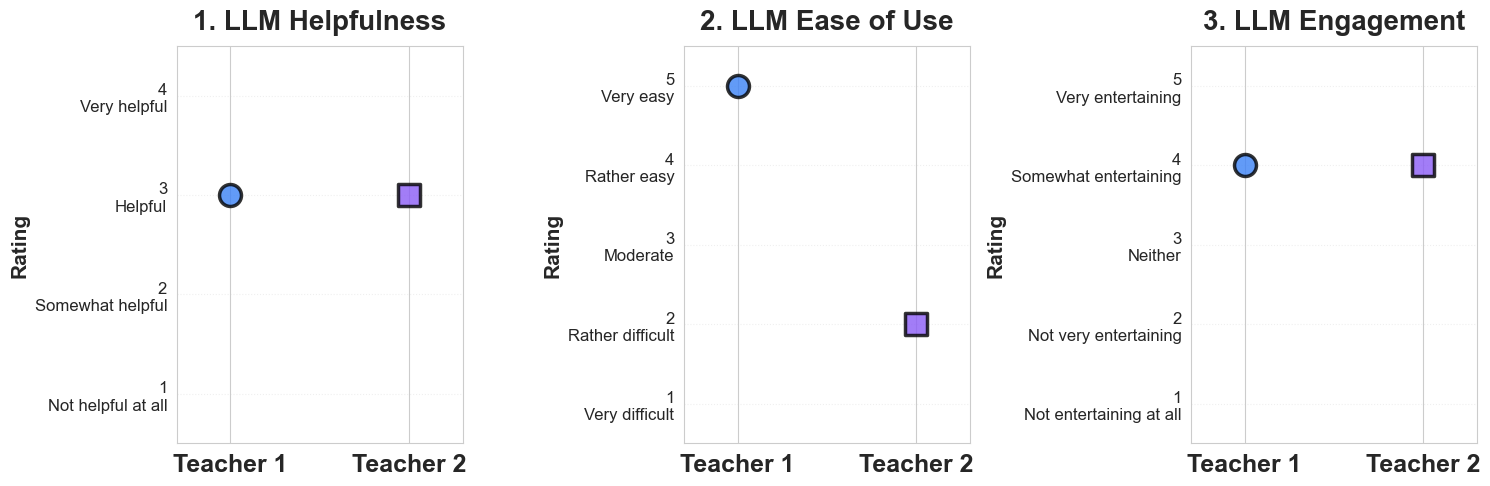

In [ ]:
# Teacher feedback visualization (N=2 at T2)
# Load teacher feedback data
df_teachers = pd.read_csv('../Data_analysis/Data/Qualtrics/BuildbotAnalysis - BuildBots_engagement_teachers.csv', skiprows=[1])

# Filter for T2 data (note: column name is 'Time point' with a space)
df_t2 = df_teachers[df_teachers['Time point'] == 'T7'].copy()

# Convert LLM-related columns to numeric
llm_vars = ['LLM_helpful', 'LLM_easy', 'LLM_engaging']
for col in llm_vars:
    df_t2[col] = pd.to_numeric(df_t2[col], errors='coerce')

# Define scale labels (excluding "I can't say" options)
helpful_labels = {1: 'Not helpful at all', 2: 'Somewhat helpful', 3: 'Helpful', 4: 'Very helpful'}
easy_labels = {1: 'Very difficult', 2: 'Rather difficult', 3: 'Moderate', 4: 'Rather easy', 5: 'Very easy'}
engaging_labels = {1: 'Not entertaining at all', 2: 'Not very entertaining', 3: 'Neither', 4: 'Somewhat entertaining', 5: 'Very entertaining'}

# Create 3 separate graphs with rating on y-axis, teachers on x-axis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

titles = ['1. LLM Helpfulness', '2. LLM Ease of Use', '3. LLM Engagement']
label_dicts = [helpful_labels, easy_labels, engaging_labels]
teachers = sorted(df_t2['Participant ID'].unique())
colors = ['#3b82f6', '#8b5cf6']  # Blue and Purple
markers = ['o', 's']  # Circle and square

for plot_idx, (var, title, labels_map) in enumerate(zip(llm_vars, titles, label_dicts)):
    ax = axes[plot_idx]
    
    # Get valid scale points (exclude "I can't say" responses)
    possible_values = sorted(labels_map.keys())
    min_rating = min(possible_values)
    max_rating = max(possible_values)
    
    # Plot each teacher's rating
    for teacher_idx, teacher in enumerate(teachers):
        teacher_data = df_t2[df_t2['Participant ID'] == teacher]
        rating = teacher_data[var].values[0] if len(teacher_data[var].dropna()) > 0 else None
        
        # Only plot if rating is valid (not "I can't say")
        if rating is not None and rating in possible_values:
            ax.scatter([teacher_idx], [rating], s=250, alpha=0.8, 
                      color=colors[teacher_idx], edgecolor='black', linewidth=2.5,
                      marker=markers[teacher_idx], zorder=3,
                      label=f'Teacher {teacher}' if plot_idx == 0 else '')
    
    ax.set_title(title, fontweight='bold', fontsize=20, pad=12)
    ax.set_xlabel('', fontsize=15)
    ax.set_ylabel('Rating', fontsize=15, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Teacher 1', 'Teacher 2'], fontsize=18, fontweight='bold')
    ax.set_ylim(min_rating - 0.5, max_rating + 0.5)
    ax.set_yticks(possible_values)
    ax.set_yticklabels([f"{v}\n{labels_map[v]}" for v in possible_values], fontsize=12)
    ax.grid(axis='y', alpha=0.3, linestyle=':')
    ax.set_xlim(-0.3, 1.3)
    

plt.tight_layout()
plt.show()

---

# Additional analysis : Learning Gains Analysis (T1 → T2)

## Does Co-creation Predict Learning Improvement?

**Learning gain:** Change from baseline (T1) to immediate post-test (T2)

**Note:** This uses **score2q** (2 basic questions) since that's the only measure available at both T1 and T2.

This tests whether students with higher co-creation showed greater knowledge improvement, not just higher final scores.

In [ ]:
%%R

# Calculate learning gains (T1 → T2 change on 2 basic questions)
df_gains <- df_scored %>%
  select(Student_ID, Group_factor, Timepoint, score2q, Cocreation_Level) %>%
  pivot_wider(names_from = Timepoint, values_from = score2q, names_prefix = "score_") %>%
  mutate(
    learning_gain = score_T2 - score_T1
  ) %>%
  filter(!is.na(learning_gain))

# Model: Learning gains predicted by co-creation
model_gains <- lm(learning_gain ~ Cocreation_Level, data = df_gains)
model_gains_robust <- coeftest(model_gains, vcov = vcovCL, cluster = ~Group_factor)

cat("\n=== LEARNING GAINS: Co-creation → (T2 - T1) Change ===\n\n")
print(model_gains_robust)

beta_gains <- coef(model_gains)["Cocreation_Level"]
p_gains <- model_gains_robust[2, 4]

cat("\n--- Interpretation ---\n")
cat(sprintf("Mean learning gain: %.2f points (on 2-question scale)\n", mean(df_gains$learning_gain)))
cat(sprintf("Co-creation effect: β = %.3f, p = %.3f\n", beta_gains, p_gains))

if (p_gains < 0.05) {
  cat("\n✓ SIGNIFICANT: Higher co-creation → Greater learning gains\n")
} else {
  cat("\n× NOT SIGNIFICANT (underpowered sample)\n")
  cat("  Effect direction suggests positive trend\n")
  cat("  Larger sample needed for confirmation\n")
}


=== LEARNING GAINS: Co-creation → (T2 - T1) Change ===


t test of coefficients:

                 Estimate Std. Error t value Pr(>|t|)  
(Intercept)      -0.11331    0.36906 -0.3070  0.76171  
Cocreation_Level  0.34103    0.14398  2.3687  0.02705 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


--- Interpretation ---
Mean learning gain: 0.29 points (on 2-question scale)
Co-creation effect: β = 0.341, p = 0.027

✓ SIGNIFICANT: Higher co-creation → Greater learning gains


`geom_smooth()` using formula = 'y ~ x'


De plus : Messages d'avis :
1: Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`). 
2: Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`). 


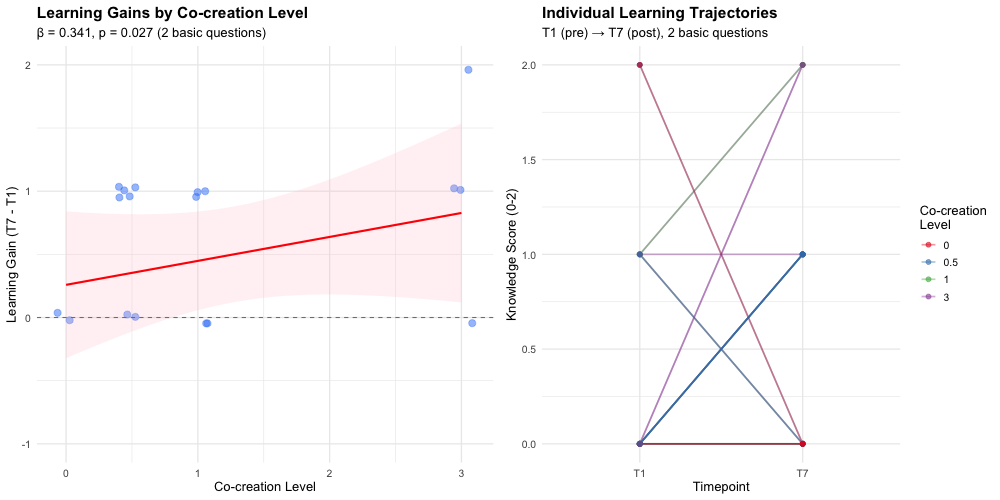

In [ ]:
%%R -w 1000 -h 500 --units px

# Visualization: Learning gains by co-creation level
p1 <- ggplot(df_gains, aes(x = Cocreation_Level, y = learning_gain)) +
  geom_jitter(width = 0.1, height = 0.05, alpha = 0.5, size = 3, color = "#3b82f6") +
  geom_smooth(method = "lm", se = TRUE, color = "red", fill = "pink", alpha = 0.2) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  labs(
    title = "Learning Gains by Co-creation Level",
    subtitle = sprintf("β = %.3f, p = %.3f (2 basic questions)", beta_gains, p_gains),
    x = "Co-creation Level",
    y = "Learning Gain (T2 - T1)"
  ) +
  ylim(-1, 2) +
  theme_minimal(base_size = 13) +
  theme(plot.title = element_text(face = "bold"))

# Show trajectory for each student (2-question score)
df_trajectory_long <- df_scored %>%
  filter(Timepoint %in% c("T1", "T2")) %>%
  select(Student_ID, Group_factor, Timepoint_factor, score2q, Cocreation_Level)

p2 <- ggplot(df_trajectory_long, aes(x = Timepoint_factor, y = score2q, 
                                     group = Student_ID)) +
  geom_line(aes(color = factor(Cocreation_Level)), alpha = 0.4, size = 0.8) +
  geom_point(aes(color = factor(Cocreation_Level)), alpha = 0.6, size = 2) +
  scale_color_brewer(palette = "Set1", name = "Co-creation\nLevel") +
  labs(
    title = "Individual Learning Trajectories",
    subtitle = "T1 (pre) → T2 (post), 2 basic questions",
    x = "Timepoint",
    y = "Knowledge Score (0-2)"
  ) +
  ylim(0, 2) +
  theme_minimal(base_size = 13) +
  theme(plot.title = element_text(face = "bold"))

gridExtra::grid.arrange(p1, p2, ncol = 2)

## Exploratory Analysis: Combined Model for Short-term and Long-term Learning

This analysis combines Model 1 (T1→T2, immediate post-test) and Model 2 (T1→T3, delayed post-test) into a single mixed-effects model. By reshaping the data to long format with two rows per participant (one for T2, one for T3), we can:

1. Include **Participant ID as a random effect** (nested within Group)
2. Test the **interaction between co-creation and timepoint** (immediate vs. delayed)
3. Control for **prior knowledge** (T1 baseline)

**Model specification:**
```
Knowledge_Score ~ T1_knowledge + co_creation * timepoint + (1 | Group_ID / Participant_ID)
```

**Note:** We use `score10q` (10 questions) as the outcome since it's available at both T2 and T3.

In [43]:
%%R

# Reshape data to long format for combined analysis
# Each participant has two rows: one for T2 (immediate) and one for T3 (delayed)

# First, get T1 baseline scores for each participant
df_t1_baseline <- df_scored %>%
  filter(Timepoint == "T1") %>%
  select(Student_ID, T1_knowledge = score2q, Group_factor, Cocreation_Level)

# Get T2 and T3 scores
df_long <- df_scored %>%
  filter(Timepoint %in% c("T2", "T3")) %>%
  select(Student_ID, Group_factor, Timepoint, Knowledge_Score = score10q, Cocreation_Level) %>%
  # Join with T1 baseline
  left_join(df_t1_baseline %>% select(Student_ID, T1_knowledge), by = "Student_ID") %>%
  # Create timepoint factor (T2 = immediate, T3 = delayed)
  mutate(
    timepoint = factor(Timepoint, levels = c("T2", "T3"), labels = c("Immediate", "Delayed")),
    Participant_ID = Student_ID,
    Group_ID = Group_factor
  ) %>%
  # Remove rows with missing values
  filter(!is.na(Knowledge_Score), !is.na(T1_knowledge), !is.na(Cocreation_Level))

cat("Data reshaped to long format:\n")
cat(sprintf("  Total observations: %d\n", nrow(df_long)))
cat(sprintf("  Participants: %d\n", n_distinct(df_long$Participant_ID)))
cat(sprintf("  Groups: %d\n", n_distinct(df_long$Group_ID)))
cat(sprintf("  Timepoints per participant: %.2f\n\n", 
            nrow(df_long) / n_distinct(df_long$Participant_ID)))

# Show structure
head(df_long %>% arrange(Participant_ID, timepoint), 10)

Data reshaped to long format:
  Total observations: 46
  Participants: 25
  Groups: 9
  Timepoints per participant: 1.84

   Student_ID Group_factor Timepoint Knowledge_Score Cocreation_Level
1           3            2        T2               9              3.0
2           3            2        T3               7              3.0
3           4            3        T2               4              1.0
4           4            3        T3               0              1.0
5           5            4        T2               6              1.0
6           5            4        T3               7              1.0
7           6            3        T2               4              1.0
8           7            4        T2               7              1.0
9           9            5        T2               7              0.5
10          9            5        T3               4              0.5
   T1_knowledge timepoint Participant_ID Group_ID
1             0 Immediate              3        2
2       

In [44]:
%%R

# Fit combined mixed-effects model
# Start with full model including nested random effects

cat("\n=== COMBINED MODEL: Short-term and Long-term Learning ===\n\n")

# Attempt full model with nested random effects
cat("Attempting full model: Knowledge_Score ~ T1_knowledge + Cocreation_Level * timepoint + (1 | Group_ID / Participant_ID)\n\n")

model_combined_full <- tryCatch({
  lmer(Knowledge_Score ~ T1_knowledge + Cocreation_Level * timepoint + 
         (1 | Group_ID / Participant_ID), 
       data = df_long,
       REML = TRUE)
}, warning = function(w) {
  if (grepl("singular", w$message, ignore.case = TRUE)) {
    cat("⚠ Singularity warning detected in full model\n")
    cat("Simplifying: Removing Group_ID random effect\n\n")
    return(NULL)
  }
  return(NULL)
})

# If singularity, simplify by removing Group random effect
if (is.null(model_combined_full)) {
  cat("Fitting simplified model: Knowledge_Score ~ T1_knowledge + Cocreation_Level * timepoint + (1 | Participant_ID)\n\n")
  
  model_combined <- lmer(Knowledge_Score ~ T1_knowledge + Cocreation_Level * timepoint + 
                           (1 | Participant_ID), 
                         data = df_long,
                         REML = TRUE)
  
  cat("✓ Simplified model converged successfully\n\n")
} else {
  model_combined <- model_combined_full
  cat("✓ Full model converged successfully\n\n")
}

# Display model summary
summary(model_combined)


=== COMBINED MODEL: Short-term and Long-term Learning ===

Attempting full model: Knowledge_Score ~ T1_knowledge + Cocreation_Level * timepoint + (1 | Group_ID / Participant_ID)

✓ Full model converged successfully

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: Knowledge_Score ~ T1_knowledge + Cocreation_Level * timepoint +  
    (1 | Group_ID/Participant_ID)
   Data: df_long

REML criterion at convergence: 179.9

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.4105 -0.3819  0.1047  0.4330  1.4944 

Random effects:
 Groups                  Name        Variance Std.Dev.
 Participant_ID:Group_ID (Intercept) 1.615    1.271   
 Group_ID                (Intercept) 0.000    0.000   
 Residual                            1.967    1.403   
Number of obs: 46, groups:  Participant_ID:Group_ID, 25; Group_ID, 9

Fixed effects:
                                  Estimate Std. Error      df t value Pr(>|t|)
(Intercept)                   

boundary (singular) fit: see help('isSingular')


In [48]:
%%R

# Fit combined mixed-effects model
# Start with full model including nested random effects

cat("\n=== COMBINED MODEL: Short-term and Long-term Learning ===\n\n")

# Attempt full model with nested random effects
cat("Attempting full model: Knowledge_Score ~ T1_knowledge + Cocreation_Level * timepoint + (1 | Group_ID / Participant_ID)\n\n")

model_combined_full <- tryCatch({
  lmer(Knowledge_Score ~ T1_knowledge + Cocreation_Level * timepoint + 
         (1 | Participant_ID), 
       data = df_long,
       REML = TRUE)
}, warning = function(w) {
  if (grepl("singular", w$message, ignore.case = TRUE)) {
    cat("⚠ Singularity warning detected in full model\n")
    cat("Simplifying: Removing Group_ID random effect\n\n")
    return(NULL)
  }
  return(NULL)
})

# If singularity, simplify by removing Group random effect
if (is.null(model_combined_full)) {
  cat("Fitting simplified model: Knowledge_Score ~ T1_knowledge + Cocreation_Level * timepoint + (1 | Participant_ID)\n\n")
  
  model_combined <- lmer(Knowledge_Score ~ T1_knowledge + Cocreation_Level * timepoint + 
                           (1 | Participant_ID), 
                         data = df_long,
                         REML = TRUE)
  
  cat("✓ Simplified model converged successfully\n\n")
} else {
  model_combined <- model_combined_full
  cat("✓ Full model converged successfully\n\n")
}

# Display model summary
summary(model_combined)


=== COMBINED MODEL: Short-term and Long-term Learning ===

Attempting full model: Knowledge_Score ~ T1_knowledge + Cocreation_Level * timepoint + (1 | Group_ID / Participant_ID)

✓ Full model converged successfully

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: Knowledge_Score ~ T1_knowledge + Cocreation_Level * timepoint +  
    (1 | Participant_ID)
   Data: df_long

REML criterion at convergence: 179.9

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.4105 -0.3819  0.1047  0.4330  1.4944 

Random effects:
 Groups         Name        Variance Std.Dev.
 Participant_ID (Intercept) 1.615    1.271   
 Residual                   1.967    1.403   
Number of obs: 46, groups:  Participant_ID, 25

Fixed effects:
                                  Estimate Std. Error      df t value Pr(>|t|)
(Intercept)                         4.8703     0.6063 32.8662   8.033 2.96e-09
T1_knowledge                       -0.1503     0.4790 23.3244  -

In [45]:
%%R

# Extract and display key results

cat("\n=== KEY RESULTS ===\n\n")

# Fixed effects
fixed_effects <- summary(model_combined)$coefficients
cat("Fixed Effects:\n")
print(fixed_effects)
cat("\n")

# Extract specific coefficients
beta_t1 <- fixed_effects["T1_knowledge", "Estimate"]
p_t1 <- fixed_effects["T1_knowledge", "Pr(>|t|)"]

beta_cocreation <- fixed_effects["Cocreation_Level", "Estimate"]
p_cocreation <- fixed_effects["Cocreation_Level", "Pr(>|t|)"]

beta_timepoint <- fixed_effects["timepointDelayed", "Estimate"]
p_timepoint <- fixed_effects["timepointDelayed", "Pr(>|t|)"]

beta_interaction <- fixed_effects["Cocreation_Level:timepointDelayed", "Estimate"]
p_interaction <- fixed_effects["Cocreation_Level:timepointDelayed", "Pr(>|t|)"]

cat("\n--- Interpretation ---\n\n")
cat(sprintf("1. T1 Knowledge (control): β = %.3f, p = %.3f\n", beta_t1, p_t1))
cat(sprintf("   %s\n\n", 
            ifelse(p_t1 < 0.05, 
                   "Prior knowledge significantly predicts post-test scores",
                   "Prior knowledge does not significantly predict post-test scores")))

cat(sprintf("2. Co-creation Level (main effect): β = %.3f, p = %.3f\n", beta_cocreation, p_cocreation))
cat(sprintf("   %s\n\n", 
            ifelse(p_cocreation < 0.05, 
                   "Co-creation level significantly predicts learning (controlling for T1)",
                   "Co-creation level does not significantly predict learning (controlling for T1)")))

cat(sprintf("3. Timepoint (Delayed vs Immediate): β = %.3f, p = %.3f\n", beta_timepoint, p_timepoint))
cat(sprintf("   %s\n\n", 
            ifelse(p_timepoint < 0.05, 
                   "Significant difference between immediate and delayed post-tests",
                   "No significant difference between immediate and delayed post-tests")))

cat(sprintf("4. Co-creation × Timepoint (interaction): β = %.3f, p = %.3f\n", beta_interaction, p_interaction))
cat(sprintf("   %s\n\n", 
            ifelse(p_interaction < 0.05, 
                   "Co-creation effect differs between immediate and delayed tests",
                   "Co-creation effect is similar for immediate and delayed tests")))

# Random effects
cat("\nRandom Effects:\n")
print(VarCorr(model_combined))
cat("\n")

# Model fit statistics
cat("Model Fit:\n")
cat(sprintf("  AIC: %.2f\n", AIC(model_combined)))
cat(sprintf("  BIC: %.2f\n", BIC(model_combined)))
cat(sprintf("  Log-likelihood: %.2f\n", logLik(model_combined)))


=== KEY RESULTS ===

Fixed Effects:
                                    Estimate Std. Error       df    t value
(Intercept)                        4.8702641  0.6063010 32.86620  8.0327490
T1_knowledge                      -0.1502941  0.4789664 23.32438 -0.3137884
Cocreation_Level                   1.1305802  0.3545450 34.86308  3.1888198
timepointDelayed                  -0.2003548  0.6114353 20.80497 -0.3276794
Cocreation_Level:timepointDelayed -0.5529091  0.3901685 20.99947 -1.4171032
                                      Pr(>|t|)
(Intercept)                       2.957100e-09
T1_knowledge                      7.564709e-01
Cocreation_Level                  3.014869e-03
timepointDelayed                  7.464286e-01
Cocreation_Level:timepointDelayed 1.711190e-01


--- Interpretation ---

1. T1 Knowledge (control): β = -0.150, p = 0.756
   Prior knowledge does not significantly predict post-test scores

2. Co-creation Level (main effect): β = 1.131, p = 0.003
   Co-creation level sign


=== MODEL DIAGNOSTICS ===



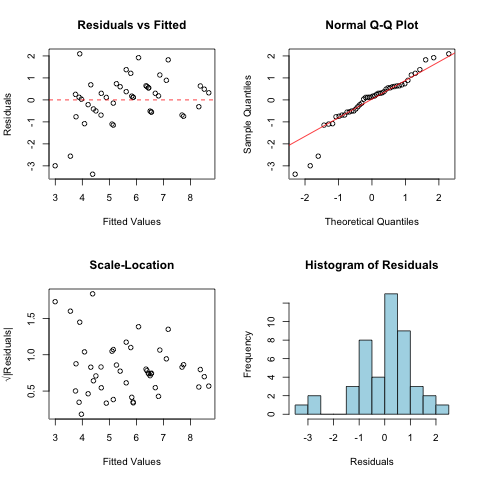

In [46]:
%%R

# Model diagnostics

cat("\n=== MODEL DIAGNOSTICS ===\n\n")

# Check assumptions
par(mfrow = c(2, 2))

# 1. Residuals vs Fitted
plot(fitted(model_combined), residuals(model_combined),
     xlab = "Fitted Values", ylab = "Residuals",
     main = "Residuals vs Fitted")
abline(h = 0, col = "red", lty = 2)

# 2. Q-Q plot
qqnorm(residuals(model_combined), main = "Normal Q-Q Plot")
qqline(residuals(model_combined), col = "red")

# 3. Scale-Location
plot(fitted(model_combined), sqrt(abs(residuals(model_combined))),
     xlab = "Fitted Values", ylab = "√|Residuals|",
     main = "Scale-Location")

# 4. Residuals histogram
hist(residuals(model_combined), breaks = 15,
     xlab = "Residuals", main = "Histogram of Residuals",
     col = "lightblue")

par(mfrow = c(1, 1))


✓ Visualization complete


De plus : Message d'avis :
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


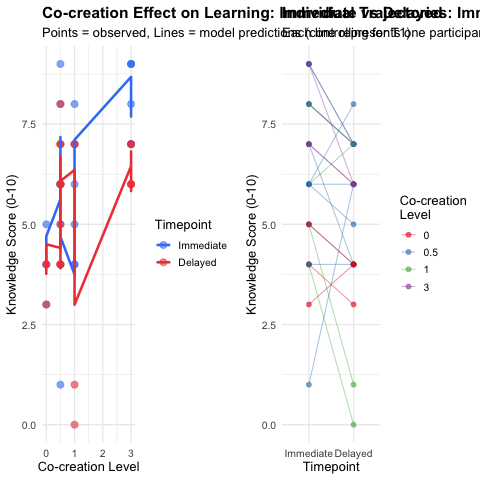

In [47]:
%%R

# Visualize the combined model results

# Predicted values for visualization
df_long$predicted <- fitted(model_combined)

# Plot 1: Observed vs Predicted by Timepoint
p1 <- ggplot(df_long, aes(x = Cocreation_Level, y = Knowledge_Score, color = timepoint)) +
  geom_point(alpha = 0.6, size = 3, position = position_jitter(width = 0.05, height = 0)) +
  geom_line(aes(y = predicted, group = timepoint), size = 1.2) +
  scale_color_manual(values = c("Immediate" = "#3b82f6", "Delayed" = "#ef4444"),
                     name = "Timepoint") +
  labs(
    title = "Co-creation Effect by Timepoint",
    x = "Co-creation Level",
    y = "Knowledge Score (0-10)"
  ) +
  ylim(0, 10) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 13),
    legend.position = "bottom",
    legend.title = element_text(size = 10),
    plot.margin = margin(10, 10, 10, 10)
  )

# Plot 2: Individual trajectories
p2 <- ggplot(df_long, aes(x = timepoint, y = Knowledge_Score, group = Participant_ID)) +
  geom_line(aes(color = factor(Cocreation_Level)), alpha = 0.4, size = 0.8) +
  geom_point(aes(color = factor(Cocreation_Level)), alpha = 0.6, size = 2.5) +
  scale_color_brewer(palette = "Set1", name = "Co-creation\nLevel") +
  labs(
    title = "Individual Trajectories",
    x = "Timepoint",
    y = "Knowledge Score (0-10)"
  ) +
  ylim(0, 10) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 13),
    legend.position = "bottom",
    legend.title = element_text(size = 10),
    plot.margin = margin(10, 10, 10, 10)
  )

gridExtra::grid.arrange(p1, p2, ncol = 2)

cat("\n✓ Visualization complete\n")